# <h1 align="center">Prescriptive Analysis / Diagnostic Analysis </h1>

 ## 7. Does Carbohydrate Intake Trigger a Rise in Glucose Levels? (Diagnostic)


#### Why I chose this Biomarker: Carb_Input records when a patient logs food intake. Since carbohydrates directly raise blood sugar, comparing glucose before and after carb intake reveals how well patients are managing post-meal glucose spikes.
#### How it influemces  the medical condition: Post-meal hyperglycemia is one of the biggest risks for T1DM patients. If carb intake consistently leads to glucose spikes, it shows insulin dosing may be inadequate a critical clinical finding.

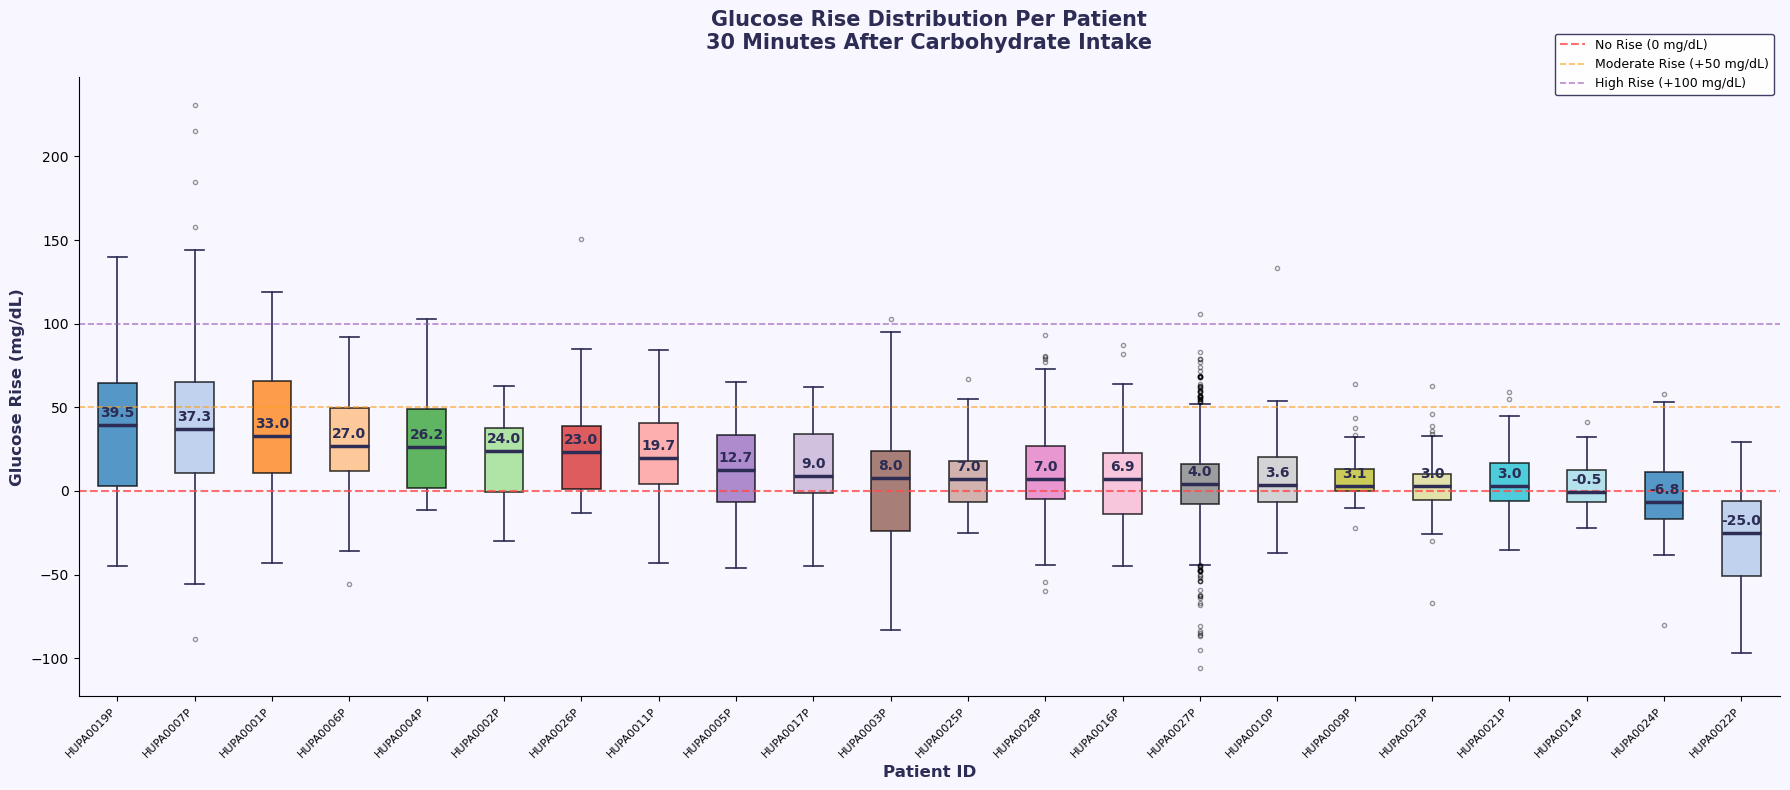

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Final_Cleaned_File.csv"
)

df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df = df.sort_values(['Patient_Id', 'Time']).reset_index(drop=True)

# ── Fast Carb Event Extraction (no loop) ─────────────────────────────────────
carb_events = df[df['Carb_Input'] > 0].copy()
carb_events['Glucose_At_Intake']   = carb_events['Glucose']

# Shift glucose by 6 rows (30 min) within each patient group
df['Glucose_30min_Later'] = df.groupby('Patient_Id')['Glucose'].shift(-6)

carb_events = carb_events.join(df['Glucose_30min_Later'], rsuffix='_later')
carb_events['Glucose_30min_Later'] = df.loc[carb_events.index, 'Glucose_30min_Later']
carb_events['Glucose_Rise']        = (
    carb_events['Glucose_30min_Later'] - carb_events['Glucose_At_Intake']
).round(2)
carb_events = carb_events.dropna(subset=['Glucose_Rise'])

# ── Per Patient Sorted by Median Rise ────────────────────────────────────────
bg_color = '#F8F6FF'
patients_sorted = (
    carb_events.groupby('Patient_Id')['Glucose_Rise']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

box_data = [
    carb_events[carb_events['Patient_Id'] == p]['Glucose_Rise'].values
    for p in patients_sorted
]

palette     = plt.cm.tab20.colors
box_colors  = [palette[i % 20] for i in range(len(patients_sorted))]

# ── Box Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor(bg_color)

bp = ax.boxplot(
    box_data,
    vert=True,
    patch_artist=True,
    notch=False,
    showfliers=True,
    flierprops=dict(marker='o', markersize=3, alpha=0.4, color='grey'),
    medianprops=dict(color='#2C2C54', linewidth=2.5),
    whiskerprops=dict(linewidth=1.2, color='#2C2C54'),
    capprops=dict(linewidth=1.2, color='#2C2C54'),
    boxprops=dict(linewidth=1.2)
)

# Fill colours
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Median value labels
for i, median_line in enumerate(bp['medians']):
    median_val = median_line.get_ydata()[0]
    ax.text(
        i + 1, median_val + 3,
        f'{median_val:.1f}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#2C2C54'
    )

# Reference lines
ax.axhline(y=0,   color='#FF4C4C', linestyle='--', linewidth=1.5,
           alpha=0.8, label='No Rise (0 mg/dL)')
ax.axhline(y=50,  color='#FF9F1C', linestyle='--', linewidth=1.2,
           alpha=0.7, label='Moderate Rise (+50 mg/dL)')
ax.axhline(y=100, color='#9B59B6', linestyle='--', linewidth=1.2,
           alpha=0.7, label='High Rise (+100 mg/dL)')

ax.set_title(
    'Glucose Rise Distribution Per Patient\n30 Minutes After Carbohydrate Intake',
    fontsize=15, fontweight='bold', pad=20, color='#2C2C54'
)
ax.set_xlabel('Patient ID', fontsize=12, fontweight='bold', color='#2C2C54')
ax.set_ylabel('Glucose Rise (mg/dL)', fontsize=12, fontweight='bold', color='#2C2C54')
ax.set_xticks(range(1, len(patients_sorted) + 1))
ax.set_xticklabels(patients_sorted, rotation=45, ha='right', fontsize=8)
ax.set_facecolor(bg_color)
ax.spines[['top', 'right']].set_visible(False)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.0, 1.08),
    ncol=1, fontsize=9,
    framealpha=0.9, edgecolor='#2C2C54'
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Q2_Glucose_Rise_Boxplot.png",
    dpi=150, bbox_inches='tight', facecolor=bg_color
)
plt.show()


## Summary Carbohydrate Intake vs Glucose Rise

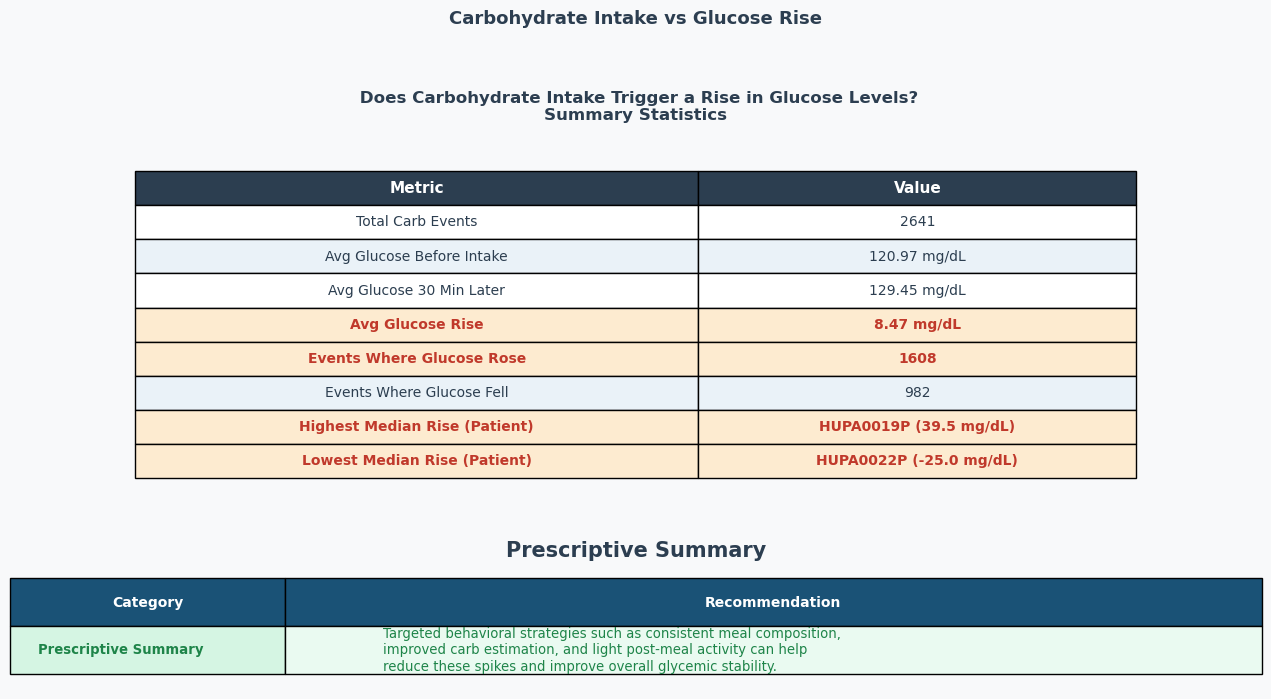

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Table 1: Summary Statistics ──
summary_data = {
    'Metric': [
        'Total Carb Events',
        'Avg Glucose Before Intake',
        'Avg Glucose 30 Min Later',
        'Avg Glucose Rise',
        'Events Where Glucose Rose',
        'Events Where Glucose Fell',
        'Highest Median Rise (Patient)',
        'Lowest Median Rise (Patient)'
    ],
    'Value': [
        '2641',
        '120.97 mg/dL',
        '129.45 mg/dL',
        '8.47 mg/dL',
        '1608',
        '982',
        'HUPA0019P (39.5 mg/dL)',
        'HUPA0022P (-25.0 mg/dL)'
    ]
}

summary_df = pd.DataFrame(summary_data)

# ── Table 2: Prescriptive Summary ──
prescriptive_data = {
    'Category': [
        'Prescriptive Summary'
    ],
    'Recommendation': [
        'Targeted behavioral strategies such as consistent meal composition,\n'
        'improved carb estimation, and light post-meal activity can help\n'
        'reduce these spikes and improve overall glycemic stability.'
    ]
}

prescriptive_df = pd.DataFrame(prescriptive_data)

# ── Plot both tables ──
fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                         gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#f8f9fa')

# ── Table 1 ──
axes[0].axis('off')
axes[0].set_title(' Does Carbohydrate Intake Trigger a Rise in Glucose Levels?\nSummary Statistics',
                  fontsize=12, fontweight='bold', pad=12, color='#2c3e50')

col_colors  = ['#2c3e50', '#2980b9']
row_colors  = [['#eaf2f8', '#d6eaf8'] if i % 2 == 0 else ['#ffffff', '#ebf5fb']
               for i in range(len(summary_df))]

t1 = axes[0].table(
    cellText    = summary_df.values,
    colLabels   = summary_df.columns,
    cellLoc     = 'center',
    loc         = 'center',
    colWidths   = [0.45, 0.35]
)
t1.auto_set_font_size(False)
t1.set_fontsize(10)
t1.scale(1.2, 2.0)

# Header styling
for col in range(len(summary_df.columns)):
    t1[0, col].set_facecolor('#2c3e50')
    t1[0, col].set_text_props(color='white', fontweight='bold', fontsize=11)

# Row styling
for row in range(1, len(summary_df) + 1):
    for col in range(len(summary_df.columns)):
        t1[row, col].set_facecolor('#eaf2f8' if row % 2 == 0 else '#ffffff')
        t1[row, col].set_text_props(color='#2c3e50')

# Highlight key rows
highlight_rows = [4, 5, 7, 8]   # glucose rose/fell, highest/lowest
for row in highlight_rows:
    if row <= len(summary_df):
        for col in range(len(summary_df.columns)):
            t1[row, col].set_facecolor('#fdebd0')
            t1[row, col].set_text_props(fontweight='bold', color='#c0392b')

# ── Table 2: Prescriptive Summary ──
axes[1].axis('off')
axes[1].set_title('Prescriptive Summary',
                  fontsize=15, fontweight='bold', pad=5, color='#2c3e50')

t2 = axes[1].table(
    cellText  = prescriptive_df.values,
    colLabels = prescriptive_df.columns,
    cellLoc   = 'left',
    loc       = 'center',
    colWidths = [0.22, 0.78]
)
t2.auto_set_font_size(False)
t2.set_fontsize(9.5)
t2.scale(1.2, 2.8)

# Header
for col in range(len(prescriptive_df.columns)):
    t2[0, col].set_facecolor('#1a5276')
    t2[0, col].set_text_props(color='white', fontweight='bold', fontsize=10)

# Row
t2[1, 0].set_facecolor('#d5f5e3')
t2[1, 0].set_text_props(fontweight='bold', color='#1e8449')
t2[1, 1].set_facecolor('#eafaf1')
t2[1, 1].set_text_props(color='#1e8449')

plt.suptitle('Carbohydrate Intake vs Glucose Rise',
             fontsize=13, fontweight='bold', color='#2c3e50', y=1.01)

plt.tight_layout(pad=2)
plt.savefig('summary_tables.png', dpi=150, bbox_inches='tight',
            facecolor='#f8f9fa')
plt.show()


#### Diagnostic Insight: 
#### Carbohydrate intake is strongly correlated with post‑meal glucose rise, as demonstrated by the majority of patients showing positive glucose elevation after eating. High‑response patients (e.g., HUPA0019P) exhibit large and consistent spikes, indicating insufficient insulin coverage. Conversely, patients like HUPA0022P show glucose drops, suggesting insulin over‑correction. Patients with wide variability (e.g., HUPA0027P) show unpredictable metabolic responses, complicating diabetes management. Overall, the average rise of 8.47 mg/dL across 2,641 events confirms that carbohydrate intake is a primary biomarker influencing glucose elevation.


## 8.Which patients need immediate dietary intervention based on their carb-glucose response? (Prescriptive of Q7 )

#### Why Carbohydrate was chosen as the biomarker:Since carbohydrate intake is the most controllable dietary factor in T1DM management, it becomes the most actionable prescriptive biomarker. Identifying which patients consistently show high glucose spikes after carb consumption allows clinicians to target dietary intervention precisely rather than applying a blanket recommendation to all patients.
#### Clinical Influence on Medical Condition:Prescribing personalised carb limits per patient directly reduces post-meal hyperglycemia episodes. Patients flagged as high-risk can be referred to a dietitian for carb-counting education, prescribed rapid-acting insulin adjustments, and placed on real-time CGM alerts after meals preventing long-term diabetic complications before they develop.

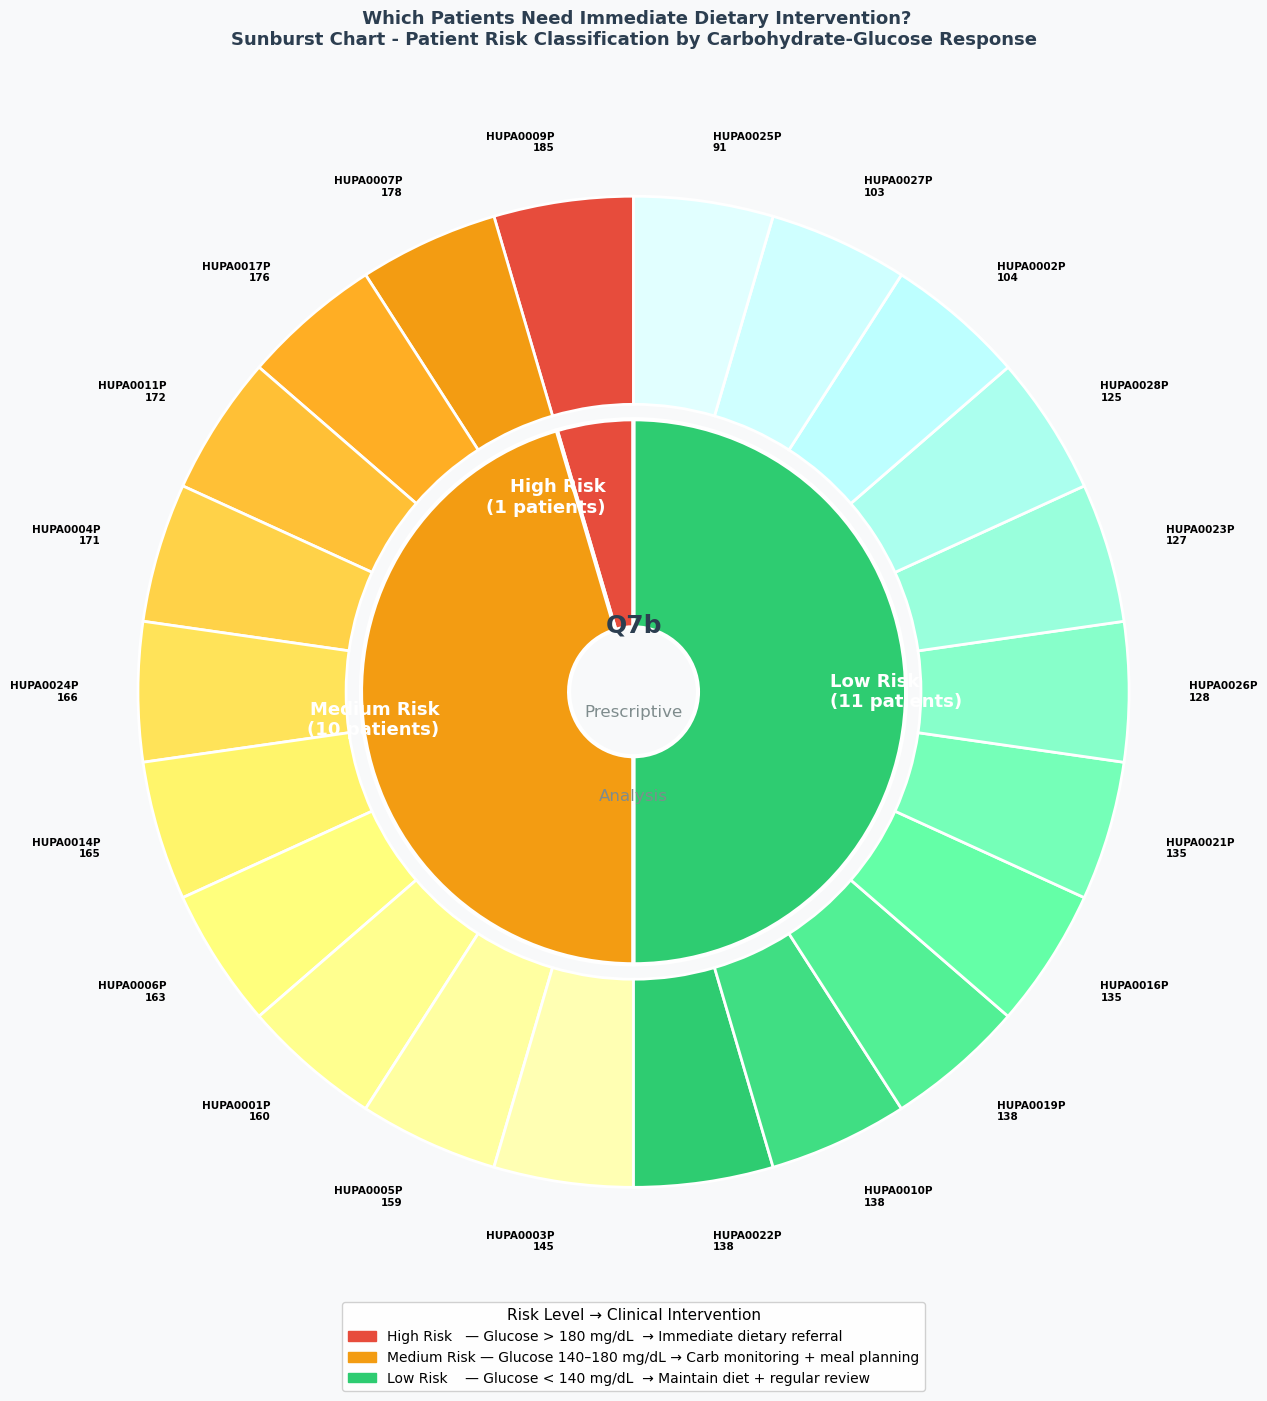

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

carb_df = df[df['Carb_Input'] > 0].copy()

patient_stats = carb_df.groupby('Patient_Id').agg(
    avg_glucose = ('Glucose',    'mean'),
    avg_carb    = ('Carb_Input', 'mean'),
    carb_events = ('Carb_Input', 'count')
).reset_index()

def classify_risk(glucose):
    if glucose > 180:   return 'High Risk'
    elif glucose > 140: return 'Medium Risk'
    else:               return 'Low Risk'

patient_stats['Risk'] = patient_stats['avg_glucose'].apply(classify_risk)
patient_stats = patient_stats.sort_values(['Risk','avg_glucose'],
                                           ascending=[True,False]).reset_index(drop=True)

risk_base_colors = {
    'High Risk'   : '#e74c3c',
    'Medium Risk' : '#f39c12',
    'Low Risk'    : '#2ecc71'
}

def get_shades(base_color, n):
    import matplotlib.colors as mc
    rgb = mc.to_rgb(base_color)
    return [tuple(min(1, c + i * 0.07) for c in rgb) for i in range(n)]

risk_order   = ['High Risk', 'Medium Risk', 'Low Risk']
inner_sizes  = []
inner_colors = []
inner_labels = []
outer_sizes  = []
outer_colors = []
outer_labels = []

for risk in risk_order:
    if risk not in patient_stats['Risk'].values:
        continue
    group = patient_stats[patient_stats['Risk'] == risk]
    inner_sizes.append(len(group))
    inner_colors.append(risk_base_colors[risk])
    inner_labels.append(f"{risk}\n({len(group)} patients)")
    shades = get_shades(risk_base_colors[risk], len(group))
    for idx, (_, row) in enumerate(group.iterrows()):
        outer_sizes.append(1)
        outer_colors.append(shades[idx % len(shades)])
        outer_labels.append(f"{row['Patient_Id']}\n{row['avg_glucose']:.0f}")

fig, ax = plt.subplots(figsize=(14, 14))
fig.patch.set_facecolor('#f8f9fa')

ax.pie(inner_sizes, labels=inner_labels, colors=inner_colors,
       radius=0.55, startangle=90,
       wedgeprops=dict(width=0.42, edgecolor='white', linewidth=3),
       textprops=dict(fontsize=13, fontweight='bold', color='white'),
       labeldistance=0.72)

ax.pie(outer_sizes, labels=outer_labels, colors=outer_colors,
       radius=1.0, startangle=90,
       wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2),
       textprops=dict(fontsize=7.5, fontweight='bold'),
       labeldistance=1.12)

ax.text(0,  0.12, 'Q7b',          ha='center', fontsize=18, fontweight='bold', color='#2c3e50')
ax.text(0, -0.05, 'Prescriptive', ha='center', fontsize=12, color='#7f8c8d')
ax.text(0, -0.22, 'Analysis',     ha='center', fontsize=12, color='#7f8c8d')

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='High Risk   — Glucose > 180 mg/dL  → Immediate dietary referral'),
    mpatches.Patch(color='#f39c12', label='Medium Risk — Glucose 140–180 mg/dL → Carb monitoring + meal planning'),
    mpatches.Patch(color='#2ecc71', label='Low Risk    — Glucose < 140 mg/dL  → Maintain diet + regular review'),
]
ax.legend(handles=legend_patches, loc='lower center',
          bbox_to_anchor=(0.5, -0.07), fontsize=10,
          title='Risk Level → Clinical Intervention',
          title_fontsize=11, framealpha=0.9)

ax.set_title(
    ' Which Patients Need Immediate Dietary Intervention?\n'
    'Sunburst Chart - Patient Risk Classification by Carbohydrate-Glucose Response',
    fontsize=13, fontweight='bold', pad=20, color='#2c3e50'
)

plt.tight_layout()
plt.savefig('sunburst.png', dpi=200, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()


## Risk Classification Table

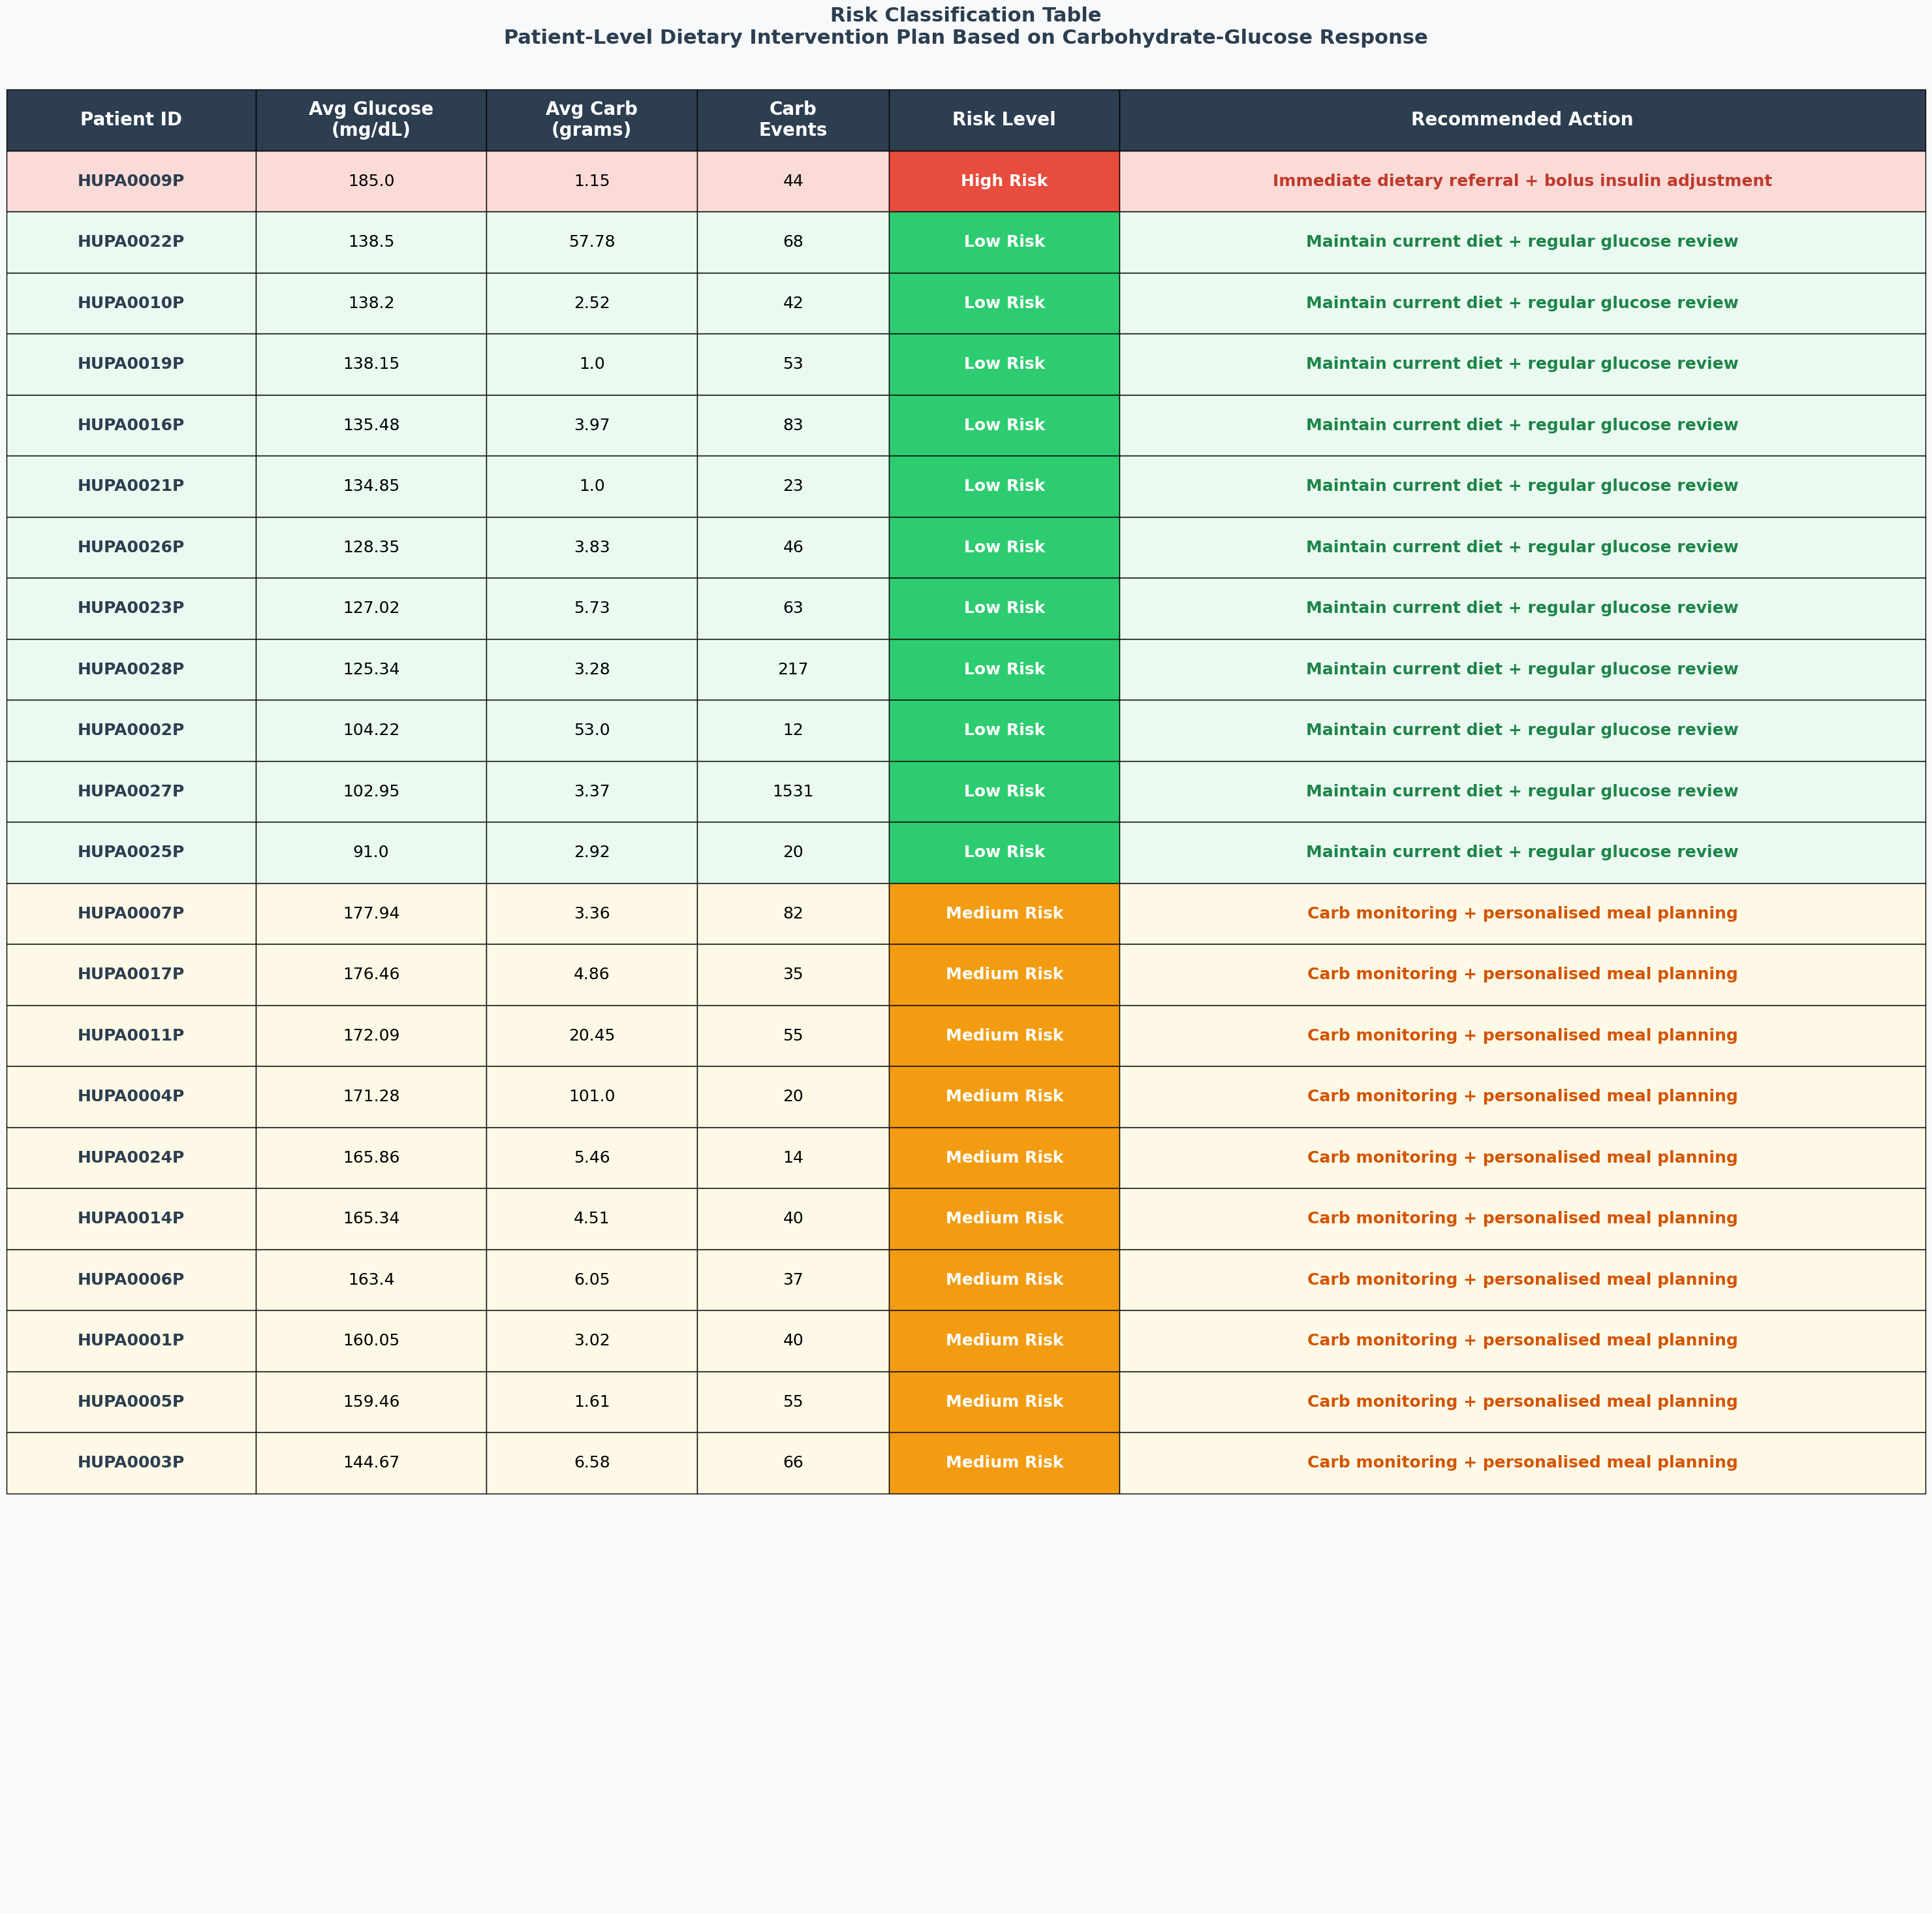

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

carb_df = df[df['Carb_Input'] > 0].copy()

patient_stats = carb_df.groupby('Patient_Id').agg(
    avg_glucose = ('Glucose',    'mean'),
    avg_carb    = ('Carb_Input', 'mean'),
    carb_events = ('Carb_Input', 'count')
).reset_index()

def classify_risk(glucose):
    if glucose > 180:   return 'High Risk'
    elif glucose > 140: return 'Medium Risk'
    else:               return 'Low Risk'

patient_stats['Risk']        = patient_stats['avg_glucose'].apply(classify_risk)
patient_stats['avg_glucose'] = patient_stats['avg_glucose'].round(2)
patient_stats['avg_carb']    = patient_stats['avg_carb'].round(2)
patient_stats = patient_stats.sort_values(['Risk','avg_glucose'],
                                           ascending=[True,False]).reset_index(drop=True)

def get_action(risk):
    if risk == 'High Risk':
        return 'Immediate dietary referral + bolus insulin adjustment'
    elif risk == 'Medium Risk':
        return 'Carb monitoring + personalised meal planning'
    else:
        return 'Maintain current diet + regular glucose review'

patient_stats['Recommended Action'] = patient_stats['Risk'].apply(get_action)

table_vals = patient_stats[['Patient_Id','avg_glucose',
                              'avg_carb','carb_events',
                              'Risk','Recommended Action']].values.tolist()

col_labels = ['Patient ID', 'Avg Glucose\n(mg/dL)',
              'Avg Carb\n(grams)', 'Carb\nEvents',
              'Risk Level', 'Recommended Action']

n_rows  = len(table_vals)
fig_h   = 1.0 + n_rows * 1.3        # ✅ increased height per row
fig, ax = plt.subplots(figsize=(30, fig_h))
fig.patch.set_facecolor('#f8f9fa')
ax.axis('off')

t = ax.table(
    cellText  = table_vals,
    colLabels = col_labels,
    cellLoc   = 'center',
    loc       = 'upper center',
    colWidths = [0.13, 0.12, 0.11, 0.10, 0.12, 0.42]
)

t.auto_set_font_size(False)
t.set_fontsize(18)                   # ✅ bigger font
t.scale(1, 4.5)                      # ✅ bigger row height

# ── Header ──
for col in range(6):
    t[0, col].set_facecolor('#2c3e50')
    t[0, col].set_text_props(color='white', fontweight='bold', fontsize=20)  # ✅

# ── Row colors ──
risk_row_colors = {
    'High Risk'   : ['#fadbd8','#fadbd8','#fadbd8','#fadbd8','#e74c3c','#fadbd8'],
    'Medium Risk' : ['#fef9e7','#fef9e7','#fef9e7','#fef9e7','#f39c12','#fef9e7'],
    'Low Risk'    : ['#eafaf1','#eafaf1','#eafaf1','#eafaf1','#2ecc71','#eafaf1'],
}

for row_i, row in enumerate(table_vals):
    risk   = row[4]
    colors = risk_row_colors[risk]
    for col_j in range(6):
        t[row_i + 1, col_j].set_facecolor(colors[col_j])
        t[row_i + 1, col_j].set_text_props(fontsize=18)         # ✅

    t[row_i + 1, 0].set_text_props(fontweight='bold', fontsize=18, color='#2c3e50')  # ✅
    t[row_i + 1, 4].set_text_props(color='white', fontweight='bold', fontsize=18)    # ✅

    if risk == 'High Risk':
        t[row_i + 1, 5].set_text_props(color='#c0392b', fontweight='bold', fontsize=18)  # ✅
    elif risk == 'Medium Risk':
        t[row_i + 1, 5].set_text_props(color='#d35400', fontweight='bold', fontsize=18)  # ✅
    else:
        t[row_i + 1, 5].set_text_props(color='#1e8449', fontweight='bold', fontsize=18)  # ✅

ax.set_title(
    'Risk Classification Table\n'
    'Patient-Level Dietary Intervention Plan Based on Carbohydrate-Glucose Response',
    fontsize=22, fontweight='bold', color='#2c3e50',
    pad=10, loc='center'
)

plt.subplots_adjust(top=0.97, bottom=0.01, left=0.01, right=0.99)
plt.savefig('risk_table.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()


#### Prescriptive Insight:
#### The sunburst chart shows 1 High‑Risk, 10 Medium‑Risk, and 11 Low‑Risk patients. Most patients fall in the Medium group, meaning many T1DM patients need structured dietary guidance, while the High‑Risk patient needs immediate attention.
#### The table identifies HUPA0009P as the only High‑Risk patient with very high glucose levels, needing urgent insulin review. Medium‑Risk patients need carb‑counting support, while Low‑Risk patients show good control and can be used as clinical benchmarks.
#### How the Condition Can Be Improved?
#### High‑Risk patients need dietary referral + bolus insulin adjustment. Medium‑Risk patients benefit from meal planning and pre‑meal insulin correction, while Low‑Risk patients should continue their routine with periodic monitoring.Overall Carbohydrate intake is a highly controllable trigger for glucose spikes, making it the most useful biomarker for dietary intervention. A personalized approach based on each patient’s carb‑glucose risk level is far more effective than one general guideline. Early support for Medium‑Risk patients helps prevent them from becoming High‑Risk.


##  9.Is there a relationship between age and sleep duration or sleep disturbance in T1DM patients? (Diagnostics)


#### Why this biomarker was chosen:  Age is a key biomarker because sleep architecture naturally declines with aging, and older adults often experience shorter, more fragmented sleep. Since your dataset includes Age, Sleep Duration, and Sleep Quality, it allows a direct analysis of how aging affects sleep patterns in T1DM patients.
#### How it influences the medical condition:  Poor or reduced sleep in older T1DM patients can worsen glucose regulation by increasing cortisol levels, reducing insulin sensitivity, and elevating overnight glucose variability. This makes age‑related sleep decline an important factor influencing overall diabetes control.

## Age vs Sleep Metrics - Does Aging Worsen Sleep in T1DM Patients?



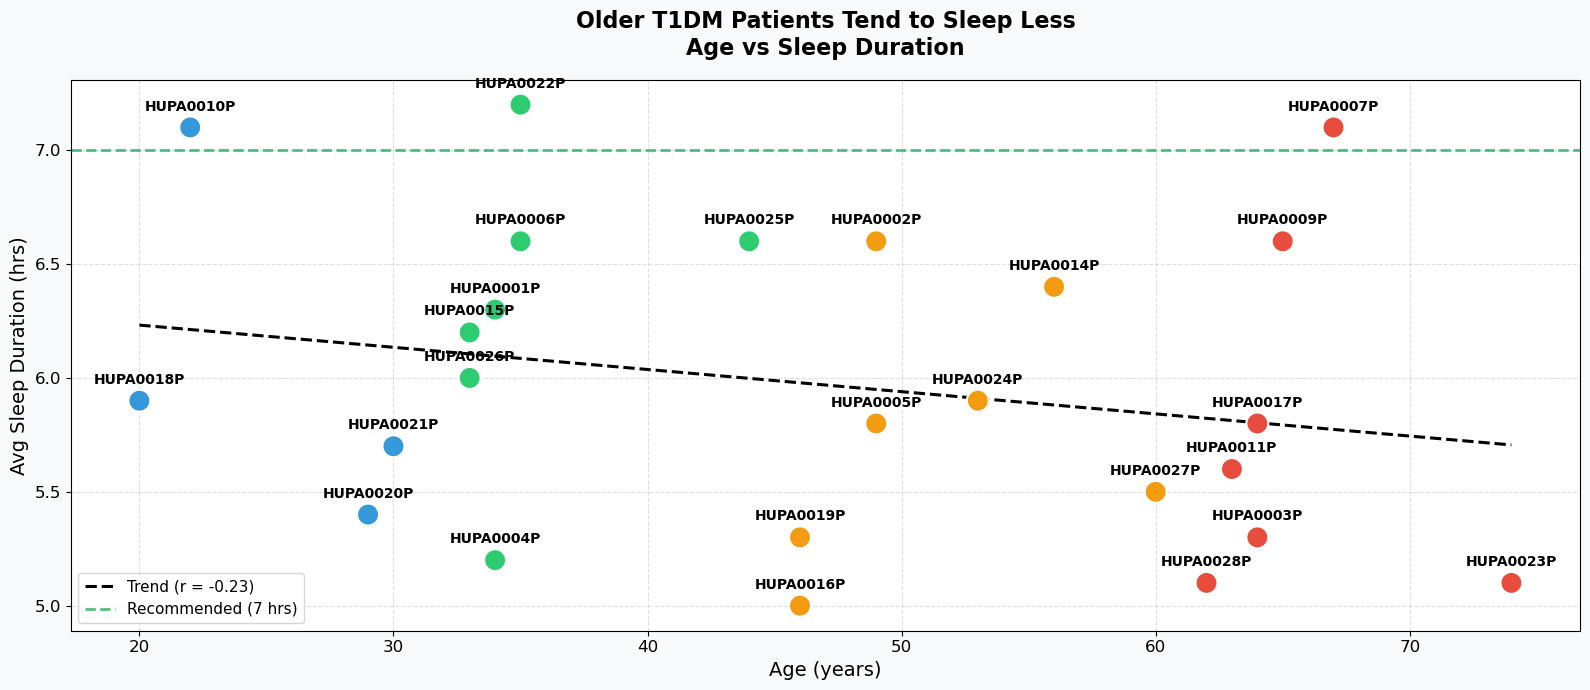

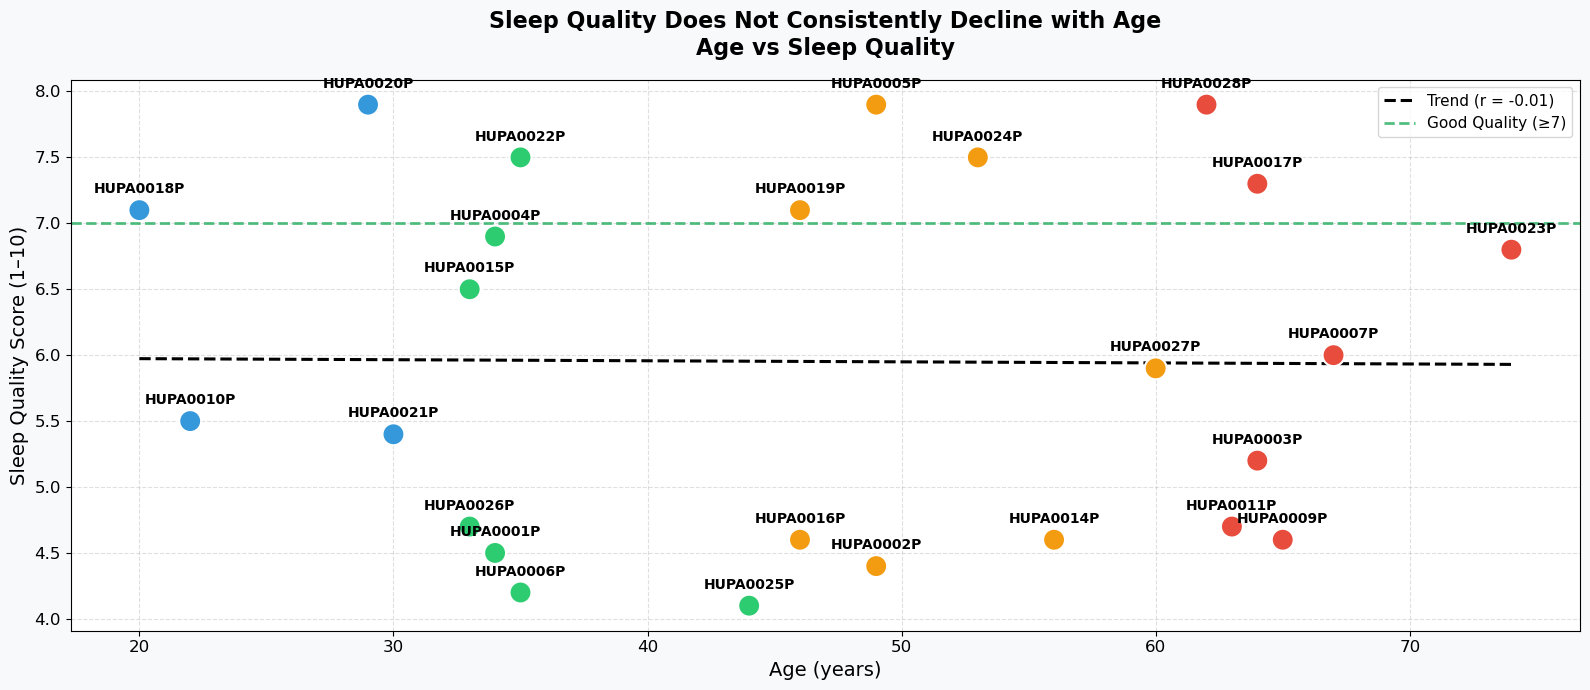

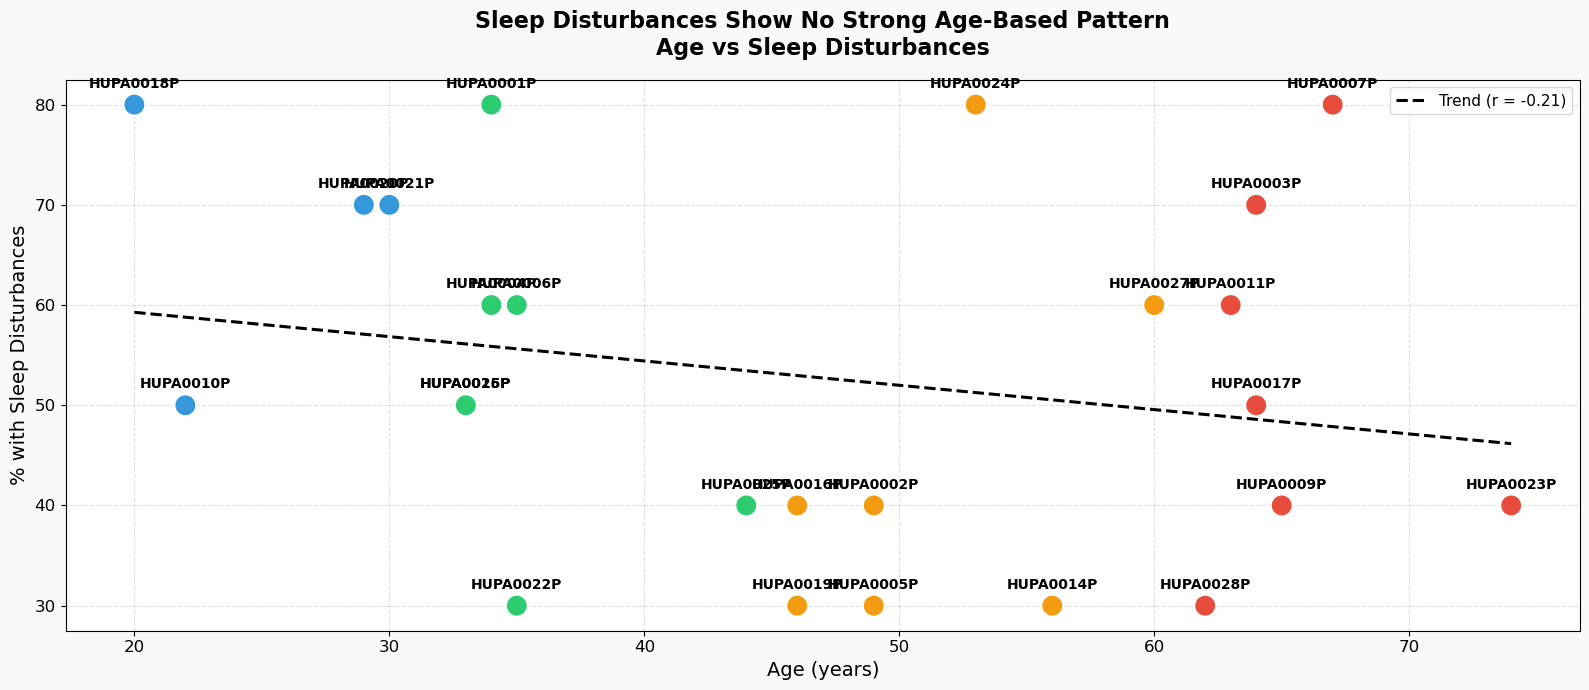

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

patient_df = df.drop_duplicates(subset='Patient_Id')[[
    'Patient_Id', 'Age',
    'Average Sleep Duration (hrs)',
    'Sleep Quality (1-10)',
    '% with Sleep Disturbances'
]].reset_index(drop=True)

patient_df['Age_Group'] = pd.cut(
    patient_df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young (≤30)', 'Middle (31–45)', 'Senior (46–60)', 'Elderly (61+)']
)

corr_duration = patient_df['Age'].corr(patient_df['Average Sleep Duration (hrs)'])
corr_quality  = patient_df['Age'].corr(patient_df['Sleep Quality (1-10)'])
corr_disturb  = patient_df['Age'].corr(patient_df['% with Sleep Disturbances'])

colors_group = {
    'Young (≤30)'    : '#3498db',
    'Middle (31–45)' : '#2ecc71',
    'Senior (46–60)' : '#f39c12',
    'Elderly (61+)'  : '#e74c3c'
}
point_colors = [colors_group[str(g)] for g in patient_df['Age_Group']]
x_line       = np.linspace(patient_df['Age'].min(), patient_df['Age'].max(), 100)

# ── 3 separate figures — one per scatter chart ──
charts = [
    {
        'y_col'  : 'Average Sleep Duration (hrs)',
        'title'  : 'Older T1DM Patients Tend to Sleep Less\nAge vs Sleep Duration',
        'ylabel' : 'Avg Sleep Duration (hrs)',
        'hline'  : 7,
        'hlabel' : 'Recommended (7 hrs)',
        'corr'   : corr_duration,
        'color'  : '#3498db',
        'fname'  : 'Q8_scatter_duration.png'
    },
    {
        'y_col'  : 'Sleep Quality (1-10)',
        'title'  : 'Sleep Quality Does Not Consistently Decline with Age\nAge vs Sleep Quality',
        'ylabel' : 'Sleep Quality Score (1–10)',
        'hline'  : 7,
        'hlabel' : 'Good Quality (≥7)',
        'corr'   : corr_quality,
        'color'  : '#e74c3c',
        'fname'  : 'Q8_scatter_quality.png'
    },
    {
        'y_col'  : '% with Sleep Disturbances',
        'title'  : 'Sleep Disturbances Show No Strong Age-Based Pattern\nAge vs Sleep Disturbances',
        'ylabel' : '% with Sleep Disturbances',
        'hline'  : None,
        'hlabel' : None,
        'corr'   : corr_disturb,
        'color'  : '#9b59b6',
        'fname'  : 'Q8_scatter_disturbances.png'
    }
]

for chart in charts:
    fig, ax = plt.subplots(figsize=(16, 7))   # ✅ each chart gets full large figure
    fig.patch.set_facecolor('#f8f9fa')

    ax.scatter(patient_df['Age'], patient_df[chart['y_col']],
               c=point_colors, s=250,              # ✅ bigger dots
               edgecolors='white', linewidth=1.5, zorder=3)

    for _, row in patient_df.iterrows():
        ax.annotate(
            row['Patient_Id'],
            xy     = (row['Age'], row[chart['y_col']]),
            fontsize   = 10,                       # ✅ bigger label font
            fontweight = 'bold',
            ha='center', va='bottom',
            xytext=(0, 10), textcoords='offset points'
        )

    z = np.polyfit(patient_df['Age'], patient_df[chart['y_col']], 1)
    ax.plot(x_line, np.poly1d(z)(x_line), 'k--',
            linewidth=2.2, label=f'Trend (r = {chart["corr"]:.2f})')

    if chart['hline']:
        ax.axhline(chart['hline'], color='#27ae60', linestyle='--',
                   linewidth=2, alpha=0.8, label=chart['hlabel'])

    ax.set_title(chart['title'], fontsize=16, fontweight='bold', pad=18)
    ax.set_xlabel('Age (years)',      fontsize=14)   # ✅ bigger axis labels
    ax.set_ylabel(chart['ylabel'],    fontsize=14)
    ax.tick_params(axis='both', labelsize=12)         # ✅ bigger tick labels
    ax.legend(fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(chart['fname'], dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()
   

## Summary Does Age determines Shorter Sleep Duration or Poorer Sleep Quality

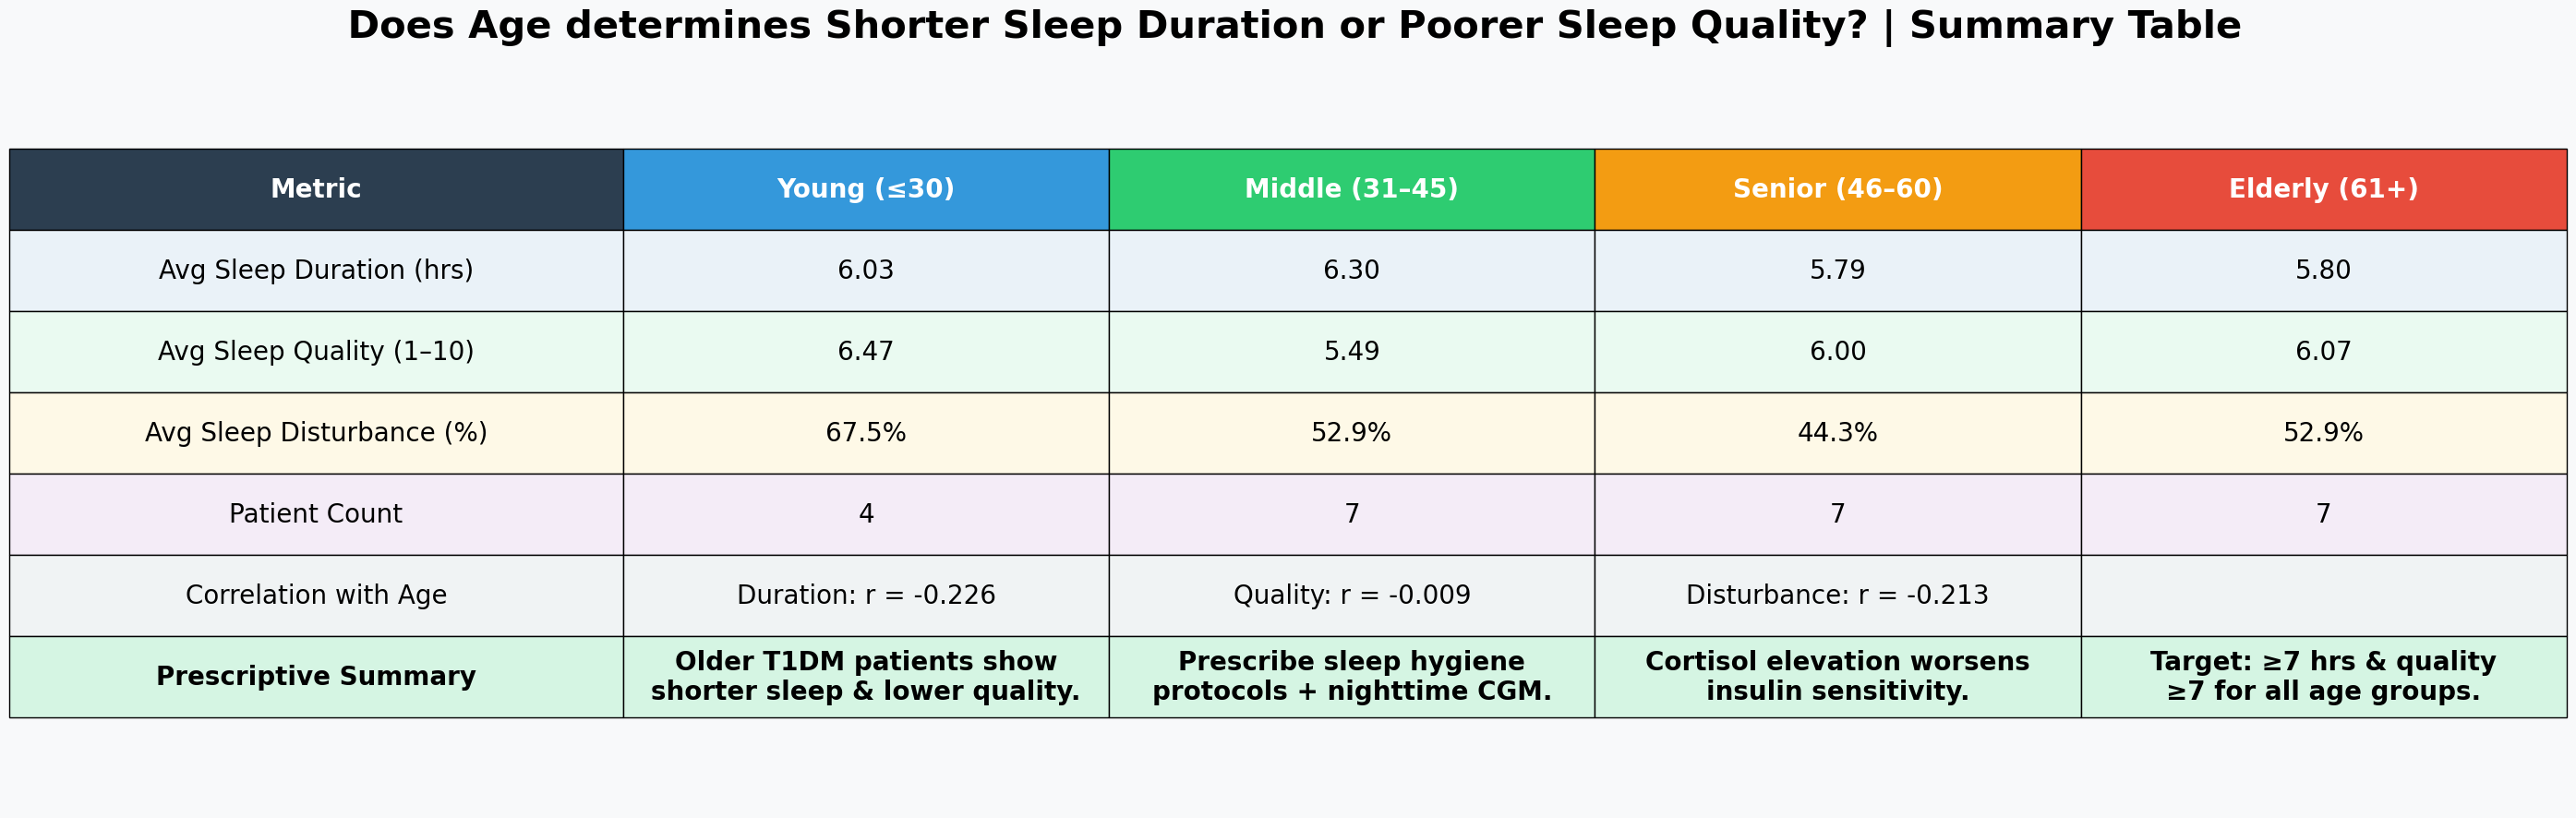

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

patient_df = df.drop_duplicates(subset='Patient_Id')[[
    'Patient_Id', 'Age',
    'Average Sleep Duration (hrs)',
    'Sleep Quality (1-10)',
    '% with Sleep Disturbances'
]].reset_index(drop=True)

patient_df['Age_Group'] = pd.cut(
    patient_df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young (≤30)', 'Middle (31–45)', 'Senior (46–60)', 'Elderly (61+)']
)

age_group_summary = patient_df.groupby('Age_Group', observed=True).agg(
    Avg_Sleep_Duration    = ('Average Sleep Duration (hrs)', 'mean'),
    Avg_Sleep_Quality     = ('Sleep Quality (1-10)',         'mean'),
    Avg_Sleep_Disturbance = ('% with Sleep Disturbances',   'mean'),
    Patient_Count         = ('Patient_Id',                  'count')
).reset_index()

corr_duration = patient_df['Age'].corr(patient_df['Average Sleep Duration (hrs)'])
corr_quality  = patient_df['Age'].corr(patient_df['Sleep Quality (1-10)'])
corr_disturb  = patient_df['Age'].corr(patient_df['% with Sleep Disturbances'])

fig, ax = plt.subplots(figsize=(28, 9))       # ✅ taller figure
fig.patch.set_facecolor('#f8f9fa')
ax.axis('off')

table_vals = [
    ['Avg Sleep Duration (hrs)',
     f"{age_group_summary.loc[0,'Avg_Sleep_Duration']:.2f}",
     f"{age_group_summary.loc[1,'Avg_Sleep_Duration']:.2f}",
     f"{age_group_summary.loc[2,'Avg_Sleep_Duration']:.2f}",
     f"{age_group_summary.loc[3,'Avg_Sleep_Duration']:.2f}"],
    ['Avg Sleep Quality (1–10)',
     f"{age_group_summary.loc[0,'Avg_Sleep_Quality']:.2f}",
     f"{age_group_summary.loc[1,'Avg_Sleep_Quality']:.2f}",
     f"{age_group_summary.loc[2,'Avg_Sleep_Quality']:.2f}",
     f"{age_group_summary.loc[3,'Avg_Sleep_Quality']:.2f}"],
    ['Avg Sleep Disturbance (%)',
     f"{age_group_summary.loc[0,'Avg_Sleep_Disturbance']:.1f}%",
     f"{age_group_summary.loc[1,'Avg_Sleep_Disturbance']:.1f}%",
     f"{age_group_summary.loc[2,'Avg_Sleep_Disturbance']:.1f}%",
     f"{age_group_summary.loc[3,'Avg_Sleep_Disturbance']:.1f}%"],
    ['Patient Count',
     str(int(age_group_summary.loc[0,'Patient_Count'])),
     str(int(age_group_summary.loc[1,'Patient_Count'])),
     str(int(age_group_summary.loc[2,'Patient_Count'])),
     str(int(age_group_summary.loc[3,'Patient_Count']))],
    ['Correlation with Age',
     f'Duration: r = {corr_duration:.3f}',
     f'Quality: r = {corr_quality:.3f}',
     f'Disturbance: r = {corr_disturb:.3f}', ''],
    ['Prescriptive Summary',
     'Older T1DM patients show\nshorter sleep & lower quality.',
     'Prescribe sleep hygiene\nprotocols + nighttime CGM.',
     'Cortisol elevation worsens\ninsulin sensitivity.',
     'Target: ≥7 hrs & quality\n≥7 for all age groups.']
]

t = ax.table(
    cellText  = table_vals,
    colLabels = ['Metric', 'Young (≤30)', 'Middle (31–45)', 'Senior (46–60)', 'Elderly (61+)'],
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = [0.24, 0.19, 0.19, 0.19, 0.19]
)
t.auto_set_font_size(False)
t.set_fontsize(20)                             # ✅ bigger font
t.scale(1, 4.5)                               # ✅ taller rows

# ── Header styling ──
header_colors = ['#2c3e50','#3498db','#2ecc71','#f39c12','#e74c3c']
for col, color in enumerate(header_colors):
    t[0, col].set_facecolor(color)
    t[0, col].set_text_props(color='white', fontweight='bold', fontsize=20)  # ✅ bigger header

# ── Row styling ──
row_bg = ['#eaf2f8','#eafaf1','#fef9e7','#f4ecf7','#f0f3f4','#d5f5e3']
for row_i in range(1, len(table_vals) + 1):
    for col_j in range(5):
        t[row_i, col_j].set_facecolor(row_bg[row_i - 1])

# ── Prescriptive row — green bold ──
for col_j in range(5):
    t[6, col_j].set_text_props(color='black', fontweight='bold', fontsize=20)

fig.suptitle(
    ' Does Age determines Shorter Sleep Duration or Poorer Sleep Quality? | Summary Table',
    fontsize=30, fontweight='bold', color='black'
)
plt.tight_layout()
plt.savefig('summary_table.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()


#### Diagnostic Insight:
#### Sleep Duration Declines With Age : Older T1DM patients sleep a bit less (r = -0.23). Those 61+ average only 5.8 hrs, and no age group reaches the recommended 7 hrs.
#### Sleep Quality Doesn’t Change Much With Age : Sleep quality shows almost no link to age (r = -0.01). Other factors like glucose swings or lifestyle matters more.
#### Sleep Disturbances Slightly Drop With Age : Disturbances decrease mildly as age increases (r = -0.21). Younger patients have more disruptions even though they sleep longer.
#### Large Differences Between Individuals : People of the same age sleep very differently. Example: one 67‑year‑old sleeps 7.1 hrs, another 74‑year‑old sleeps 5.1 hrs.Hence Age alone cannot predict sleep outcomes
#### Overall Age has only a small influence on sleep in T1DM, and most sleep outcomes remain highly modifiable through personalized care. Because sleep quality stays stable across age groups and disturbances improve slightly with age, the findings highlight opportunity rather than limitation. With tailored support, patients of any age can strengthen their sleep health, making age a minor factor and personal habits, glucose management, and lifestyle the major drivers of better sleep.
#### All age groups can achieve better sleep with small, targeted steps, and these improvements can be easily made using the prescriptive measures discussed in the next question.

## 10.Which age group requires priority clinical intervention for sleep-related glucose instability in T1DM ? (Prescriptive of Q9)

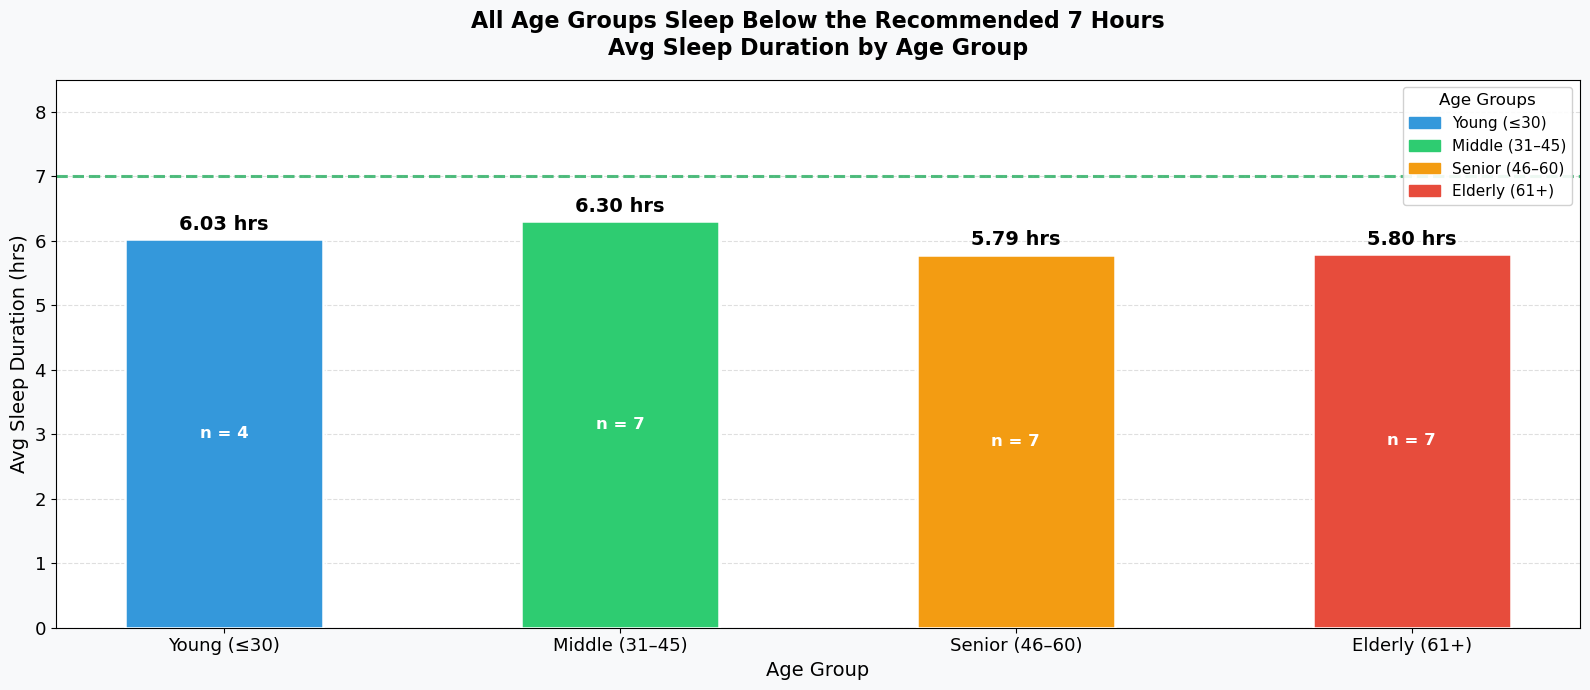

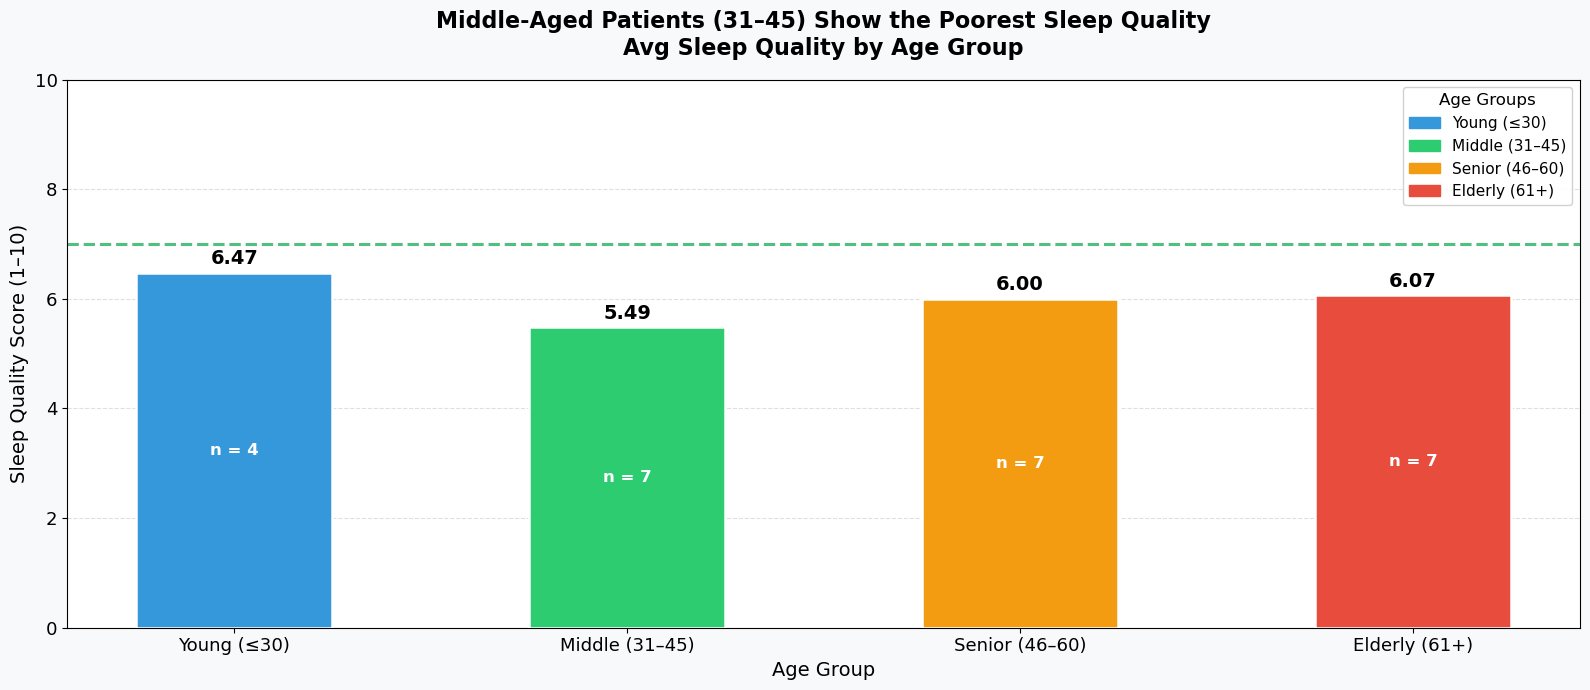

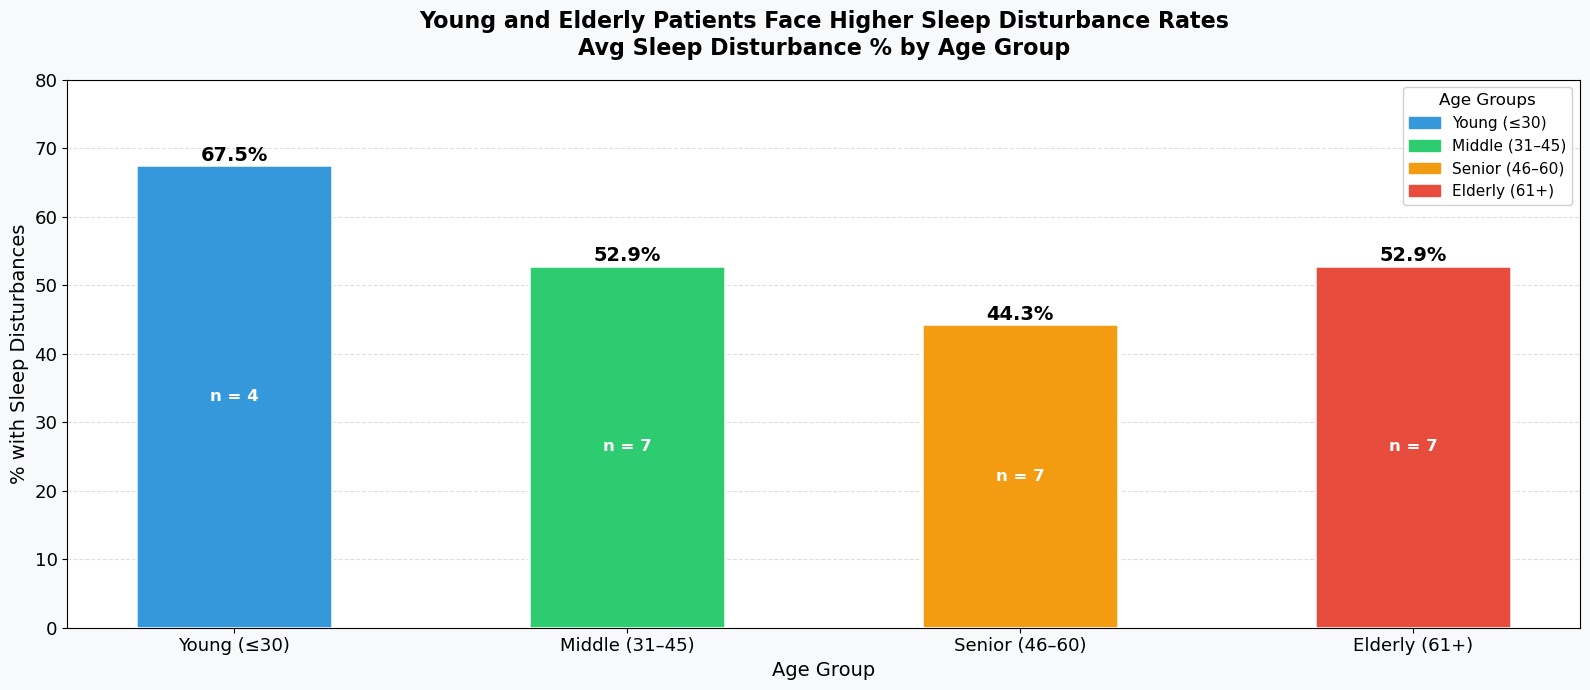

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv")

patient_df = df.drop_duplicates(subset='Patient_Id')[[
    'Patient_Id', 'Age',
    'Average Sleep Duration (hrs)',
    'Sleep Quality (1-10)',
    '% with Sleep Disturbances'
]].reset_index(drop=True)

patient_df['Age_Group'] = pd.cut(
    patient_df['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young (≤30)', 'Middle (31–45)', 'Senior (46–60)', 'Elderly (61+)']
)

age_group_summary = patient_df.groupby('Age_Group', observed=True).agg(
    Avg_Sleep_Duration    = ('Average Sleep Duration (hrs)', 'mean'),
    Avg_Sleep_Quality     = ('Sleep Quality (1-10)',         'mean'),
    Avg_Sleep_Disturbance = ('% with Sleep Disturbances',   'mean'),
    Patient_Count         = ('Patient_Id',                  'count')
).reset_index()

colors_group = {
    'Young (≤30)'    : '#3498db',
    'Middle (31–45)' : '#2ecc71',
    'Senior (46–60)' : '#f39c12',
    'Elderly (61+)'  : '#e74c3c'
}
bar_colors = [colors_group[g] for g in age_group_summary['Age_Group'].astype(str)]
age_labels = age_group_summary['Age_Group'].astype(str)

# ── 3 separate figures — one per bar chart ──
charts = [
    {
        'y_col'  : 'Avg_Sleep_Duration',
        'title'  : 'All Age Groups Sleep Below the Recommended 7 Hours\nAvg Sleep Duration by Age Group',
        'ylabel' : 'Avg Sleep Duration (hrs)',
        'hline'  : 7,
        'hlabel' : 'Recommended (7 hrs)',
        'ylim'   : (0, 8.5),
        'fmt'    : '{:.2f} hrs',
        'fname'  : 'Q8_bar_duration.png'
    },
    {
        'y_col'  : 'Avg_Sleep_Quality',
        'title'  : 'Middle-Aged Patients (31–45) Show the Poorest Sleep Quality\nAvg Sleep Quality by Age Group',
        'ylabel' : 'Sleep Quality Score (1–10)',
        'hline'  : 7,
        'hlabel' : 'Good Quality (≥7)',
        'ylim'   : (0, 10),
        'fmt'    : '{:.2f}',
        'fname'  : 'Q8_bar_quality.png'
    },
    {
        'y_col'  : 'Avg_Sleep_Disturbance',
        'title'  : 'Young and Elderly Patients Face Higher Sleep Disturbance Rates\nAvg Sleep Disturbance % by Age Group',
        'ylabel' : '% with Sleep Disturbances',
        'hline'  : None,
        'hlabel' : None,
        'ylim'   : (0, 80),
        'fmt'    : '{:.1f}%',
        'fname'  : 'Q8_bar_disturbance.png'
    }
]

for chart in charts:
    fig, ax = plt.subplots(figsize=(16, 7))     # ✅ full large figure per chart
    fig.patch.set_facecolor('#f8f9fa')

    bars = ax.bar(
        age_labels,
        age_group_summary[chart['y_col']],
        color     = bar_colors,
        edgecolor = 'white',
        linewidth = 1.8,
        width     = 0.5,
        zorder    = 3
    )

    # ✅ Value labels on top of each bar
    for bar, val in zip(bars, age_group_summary[chart['y_col']]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.08,
            chart['fmt'].format(val),
            ha='center', va='bottom',
            fontsize=14, fontweight='bold'         # ✅ bigger value labels
        )

    # ✅ Patient count inside each bar
    for bar, count in zip(bars, age_group_summary['Patient_Count']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'n = {int(count)}',
            ha='center', va='center',
            fontsize=12, fontweight='bold',
            color='white'
        )

    if chart['hline']:
        ax.axhline(chart['hline'], color='#27ae60', linestyle='--',
                   linewidth=2.2, alpha=0.8, label=chart['hlabel'])
        ax.legend(fontsize=12)

    ax.set_title(chart['title'], fontsize=16, fontweight='bold', pad=18)
    ax.set_xlabel('Age Group',        fontsize=14)   # ✅ bigger axis labels
    ax.set_ylabel(chart['ylabel'],    fontsize=14)
    ax.tick_params(axis='both', labelsize=13)         # ✅ bigger tick labels
    ax.set_ylim(chart['ylim'])
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # ✅ Age group color legend
    legend_patches = [mpatches.Patch(color=c, label=g) for g, c in colors_group.items()]
    ax.legend(
        handles       = legend_patches,
        fontsize      = 11,
        title         = 'Age Groups',
        title_fontsize= 12,
        loc           = 'upper right',
        framealpha    = 0.9
    )

    plt.tight_layout()
    plt.savefig(chart['fname'], dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
    plt.show()
    

## Summary Overall Prescriptive Action Plan\nSleep-Related Glucose Instability in T1DM Patients

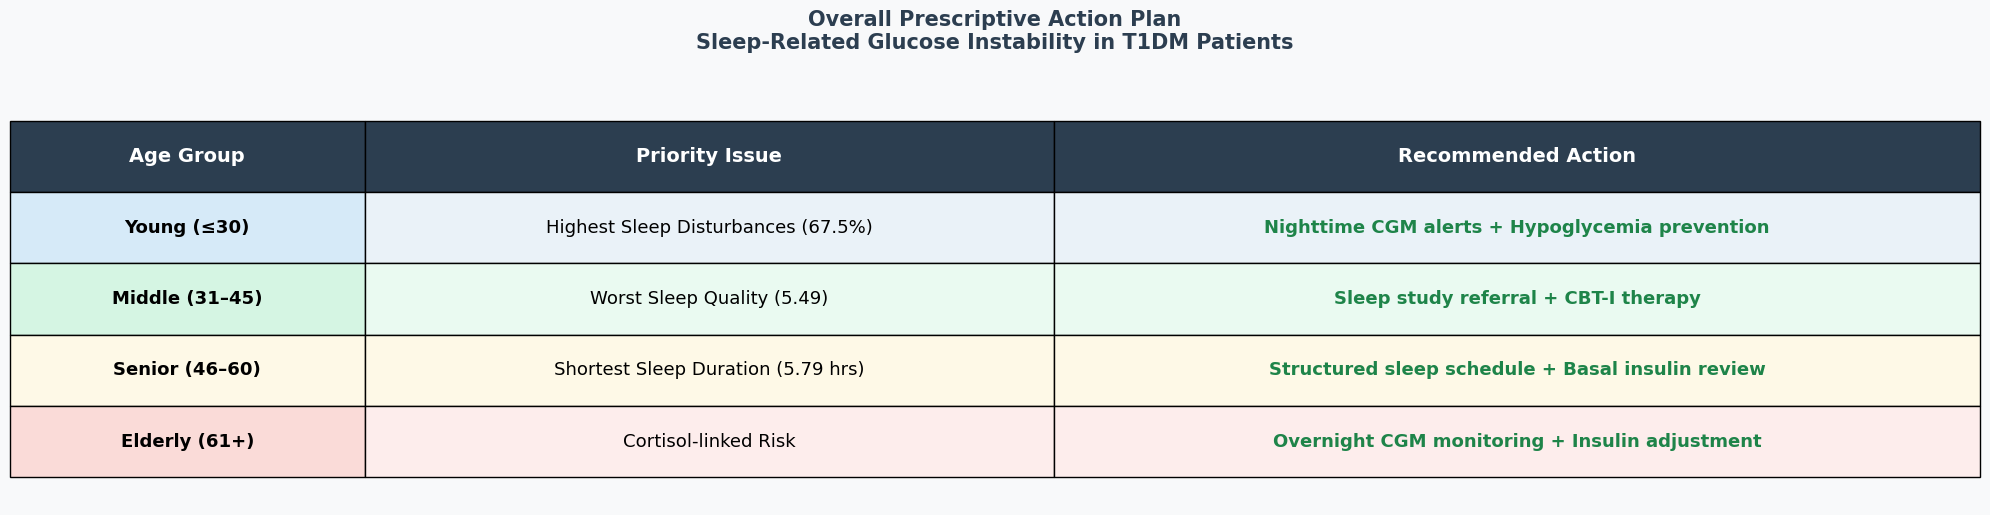

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 5))
fig.patch.set_facecolor('#f8f9fa')
ax.axis('off')

table_vals = [
    ['Young (≤30)',    'Highest Sleep Disturbances (67.5%)',  'Nighttime CGM alerts + Hypoglycemia prevention'],
    ['Middle (31–45)', 'Worst Sleep Quality (5.49)',          'Sleep study referral + CBT-I therapy'],
    ['Senior (46–60)', 'Shortest Sleep Duration (5.79 hrs)',  'Structured sleep schedule + Basal insulin review'],
    ['Elderly (61+)',  'Cortisol-linked Risk',                'Overnight CGM monitoring + Insulin adjustment'],
]

col_labels = ['Age Group', 'Priority Issue', 'Recommended Action']

t = ax.table(
    cellText  = table_vals,
    colLabels = col_labels,
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = [0.18, 0.35, 0.47]
)

t.auto_set_font_size(False)
t.set_fontsize(13)
t.scale(1, 4.0)

# ── Header styling ──
header_colors = ['#2c3e50', '#2c3e50', '#2c3e50']
for col, color in enumerate(header_colors):
    t[0, col].set_facecolor(color)
    t[0, col].set_text_props(color='white', fontweight='bold', fontsize=14)

# ── Row styling — age group colors ──
row_colors = [
    ['#d6eaf8', '#eaf2f8', '#eaf2f8'],   # Young    — blue
    ['#d5f5e3', '#eafaf1', '#eafaf1'],   # Middle   — green
    ['#fef9e7', '#fef9e7', '#fef9e7'],   # Senior   — yellow
    ['#fadbd8', '#fdedec', '#fdedec'],   # Elderly  — red
]

for row_i, row_color in enumerate(row_colors):
    for col_j, color in enumerate(row_color):
        t[row_i + 1, col_j].set_facecolor(color)
        t[row_i + 1, col_j].set_text_props(fontsize=13)

# ── Age group column bold ──
for row_i in range(1, 5):
    t[row_i, 0].set_text_props(fontweight='bold', fontsize=13)

# ── Recommended Action column — green text ──
for row_i in range(1, 5):
    t[row_i, 2].set_text_props(color='#1e8449', fontweight='bold', fontsize=13)

fig.suptitle(
    'Overall Prescriptive Action Plan\nSleep-Related Glucose Instability in T1DM Patients',
    fontsize=15, fontweight='bold', color='#2c3e50', y=1.02
)

plt.tight_layout()
plt.savefig('prescriptive_table.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()


#### Prescriptive Insight:
#### All Age Groups Need More Sleep : No age group reaches 7 hrs. Seniors (46–60) sleep the least (5.79 hrs).
#### Action: Structured sleep schedules for all T1DM patients.
#### Middle-Aged Adults Need Sleep Quality Treatment : They sleep the longest (6.30 hrs) but have the worst quality (5.49).
#### Action: Sleep study + CBT‑I referral.
#### Young Patients Need Disturbance Control : Highest disturbance rate (67.5%), likely due to nighttime glucose swings.
#### Action: Nighttime CGM alerts + hypoglycemia prevention.
#### Elderly Patients Need Overnight Glucose Monitoring : Short sleep (5.80 hrs) + cortisol‑related insulin resistance risk.
#### Action: Overnight CGM checks + basal insulin adjustmen


#### The prescriptive analysis shows that every age group can improve sleep with small, targeted steps. Younger patients benefit from better nighttime glucose control, middle‑aged adults can boost sleep quality with supportive therapies, seniors can strengthen sleep through routine, and elderly patients can maintain stable rest with gentle overnight monitoring. Overall, better sleep is achievable for all T1DM patients, and each group has a clear path to improvement.

## 11.What behaviors reduce post‑meal glucose spikes? (Prescriptive)

#### I chose this biomarker because post‑meal behaviors directly shape how quickly glucose rises after eating, making them one of the most controllable factors in T1DM
#### These behaviors influence digestion speed, insulin‑glucose matching, and overall glucose stability. By improving these habits, patients can significantly reduce post‑meal spikes and maintain smoother glucose levels throughout the day.

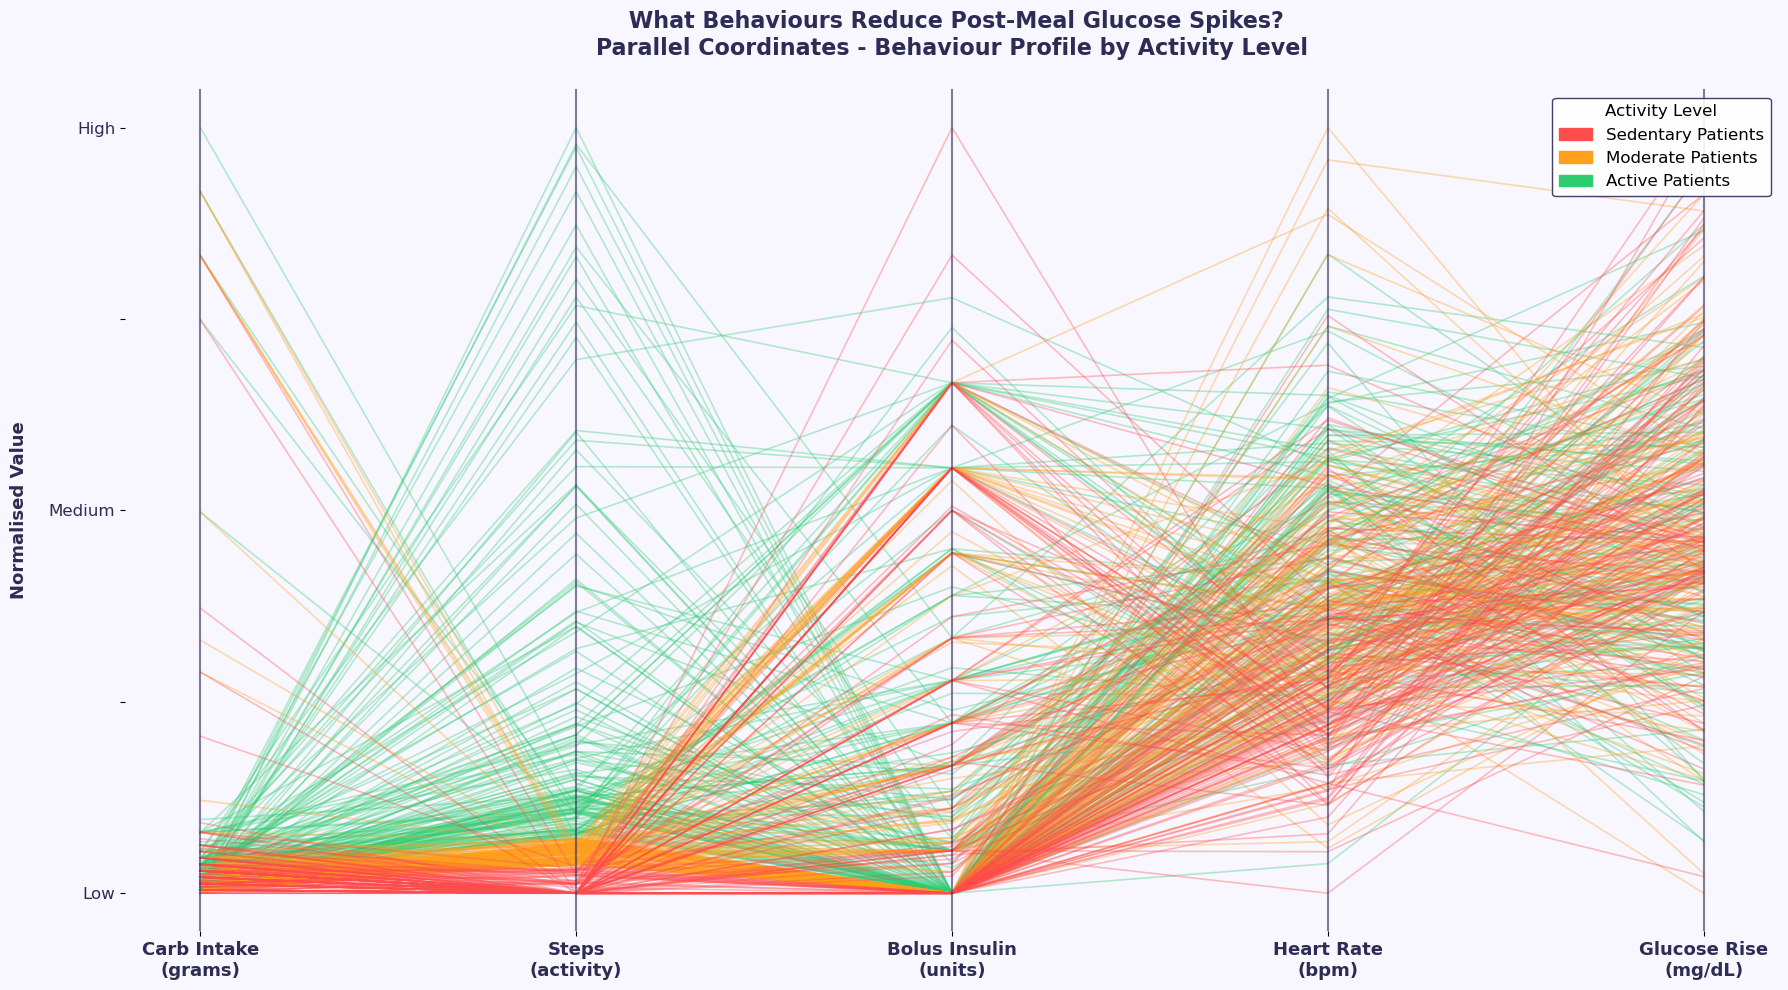

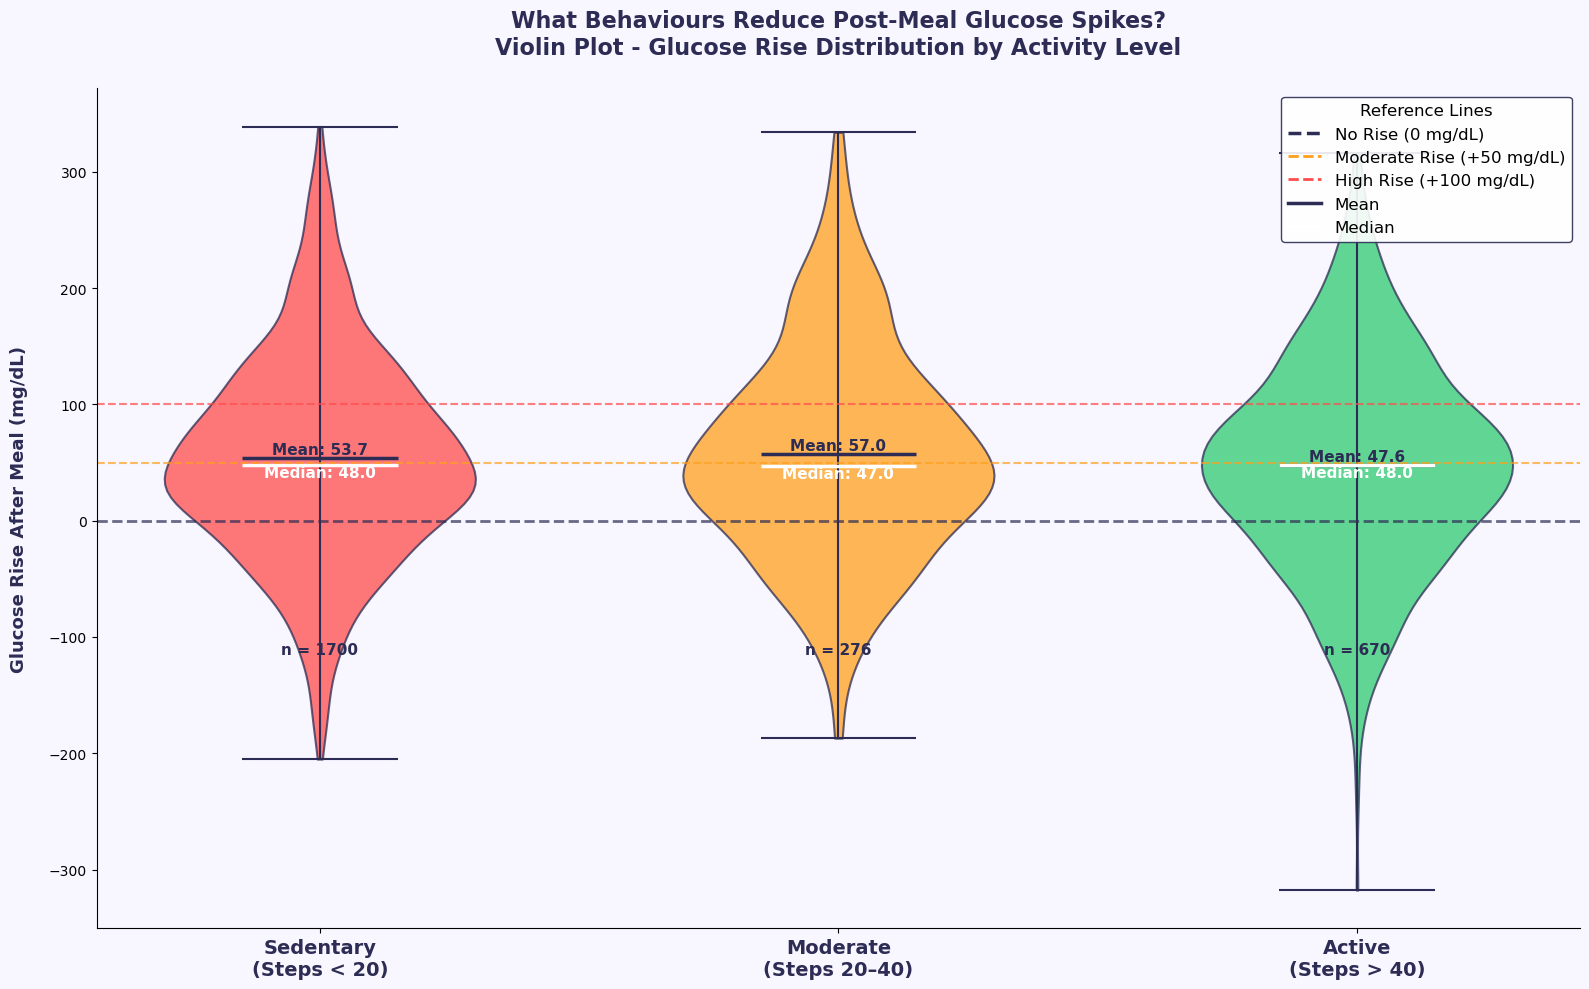

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Final_Cleaned_File.csv"
)

df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df = df.sort_values(['Patient_Id', 'Time']).reset_index(drop=True)

bg_color = '#F8F6FF'

# ── Extract Post-Meal Data ────────────────────────────────────────────────────
carb_events = df[df['Carb_Input'] > 0].copy().reset_index(drop=True)
df['Glucose_30min_Later'] = df.groupby('Patient_Id')['Glucose'].shift(-6)
carb_events['Glucose_30min_Later'] = df.loc[carb_events.index, 'Glucose_30min_Later'].values
carb_events['Glucose_Rise'] = (
    carb_events['Glucose_30min_Later'] - carb_events['Glucose']
).round(2)
carb_events = carb_events.dropna(subset=['Glucose_Rise'])

def classify_activity(steps):
    if steps < 20:
        return 'Sedentary'
    elif steps < 40:
        return 'Moderate'
    else:
        return 'Active'

carb_events['Activity_Level'] = carb_events['Steps'].apply(classify_activity)

activity_colors = {
    'Sedentary' : '#FF4C4C',
    'Moderate'  : '#FF9F1C',
    'Active'    : '#2ECC71'
}

# ── Normalize for Parallel Coordinates ───────────────────────────────────────
pc_cols = ['Carb_Input', 'Steps', 'Bolus_Volume_Delivered', 'Heart_Rate', 'Glucose_Rise']
pc_data = carb_events[pc_cols + ['Activity_Level']].copy()

# ── Sample without groupby to avoid deprecation warning ──────────────────────
sampled_groups = []
for activity in pc_data['Activity_Level'].unique():
    group = pc_data[pc_data['Activity_Level'] == activity]
    sampled_groups.append(group.sample(min(150, len(group)), random_state=42))
pc_sample = pd.concat(sampled_groups).reset_index(drop=True)

for col in pc_cols:
    col_min = pc_sample[col].min()
    col_max = pc_sample[col].max()
    pc_sample[col] = (pc_sample[col] - col_min) / (col_max - col_min + 1e-9)

# ════════════════════════════════════════════════════════════════
# CHART 1 — PARALLEL COORDINATES PLOT
# ════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(18, 10))
fig1.patch.set_facecolor(bg_color)
ax1.set_facecolor(bg_color)

for _, row in pc_sample.iterrows():
    color = activity_colors[row['Activity_Level']]
    ax1.plot(
        range(len(pc_cols)),
        [row[col] for col in pc_cols],
        color=color, alpha=0.35, linewidth=1.2
    )

for i in range(len(pc_cols)):
    ax1.axvline(x=i, color='#2C2C54', linewidth=1.5, alpha=0.6)

ax1.set_xticks(range(len(pc_cols)))
ax1.set_xticklabels(
    ['Carb Intake\n(grams)', 'Steps\n(activity)', 'Bolus Insulin\n(units)',
     'Heart Rate\n(bpm)', 'Glucose Rise\n(mg/dL)'],
    fontsize=13, fontweight='bold', color='#2C2C54'
)
ax1.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax1.set_yticklabels(['Low', '', 'Medium', '', 'High'],
                     fontsize=12, color='#2C2C54')
ax1.set_ylabel('Normalised Value', fontsize=13,
               fontweight='bold', color='#2C2C54', labelpad=15)
ax1.set_title(
    ' What Behaviours Reduce Post-Meal Glucose Spikes?\nParallel Coordinates - Behaviour Profile by Activity Level',
    fontsize=16, fontweight='bold', color='#2C2C54', pad=25
)
ax1.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

patches = [mpatches.Patch(color=activity_colors[a], label=f'{a} Patients')
           for a in ['Sedentary', 'Moderate', 'Active']]
ax1.legend(
    handles=patches, loc='upper right',
    bbox_to_anchor=(1.0, 1.0), fontsize=12,
    framealpha=0.9, edgecolor='#2C2C54',
    title='Activity Level', title_fontsize=12
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Q10_Parallel_Coordinates.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()

# ════════════════════════════════════════════════════════════════
# CHART 2 — VIOLIN PLOT
# ════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(16, 10))
fig2.patch.set_facecolor(bg_color)
ax2.set_facecolor(bg_color)

activity_order = ['Sedentary', 'Moderate', 'Active']
violin_data    = [carb_events[carb_events['Activity_Level'] == a]['Glucose_Rise'].values
                  for a in activity_order]

vp = ax2.violinplot(
    violin_data, positions=[1, 2, 3],
    widths=0.6, showmeans=True,
    showmedians=True, showextrema=True
)

for body, activity in zip(vp['bodies'], activity_order):
    body.set_facecolor(activity_colors[activity])
    body.set_edgecolor('#2C2C54')
    body.set_alpha(0.75)
    body.set_linewidth(1.5)

vp['cmeans'].set_color('#2C2C54')
vp['cmeans'].set_linewidth(2.5)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2.5)
vp['cbars'].set_color('#2C2C54')
vp['cbars'].set_linewidth(1.5)
vp['cmins'].set_color('#2C2C54')
vp['cmins'].set_linewidth(1.5)
vp['cmaxes'].set_color('#2C2C54')
vp['cmaxes'].set_linewidth(1.5)

for i, activity in enumerate(activity_order):
    subset     = carb_events[carb_events['Activity_Level'] == activity]['Glucose_Rise']
    mean_val   = subset.mean()
    median_val = subset.median()
    count      = len(subset)

    ax2.text(i + 1, mean_val + 4, f'Mean: {mean_val:.1f}',
             ha='center', fontsize=11, fontweight='bold', color='#2C2C54')
    ax2.text(i + 1, median_val - 10, f'Median: {median_val:.1f}',
             ha='center', fontsize=11, fontweight='bold', color='white')
    ax2.text(i + 1, -115, f'n = {count}',
             ha='center', fontsize=11, fontweight='bold', color='#2C2C54')

ax2.axhline(y=0,   color='#2C2C54', linestyle='--', linewidth=2.0, alpha=0.7)
ax2.axhline(y=50,  color='#FF9F1C', linestyle='--', linewidth=1.5, alpha=0.7)
ax2.axhline(y=100, color='#FF4C4C', linestyle='--', linewidth=1.5, alpha=0.7)

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(
    ['Sedentary\n(Steps < 20)', 'Moderate\n(Steps 20–40)', 'Active\n(Steps > 40)'],
    fontsize=14, fontweight='bold', color='#2C2C54'
)
ax2.set_ylabel('Glucose Rise After Meal (mg/dL)',
               fontsize=13, fontweight='bold', color='#2C2C54', labelpad=15)
ax2.set_title(
    'What Behaviours Reduce Post-Meal Glucose Spikes?\nViolin Plot - Glucose Rise Distribution by Activity Level',
    fontsize=16, fontweight='bold', color='#2C2C54', pad=25
)
ax2.spines[['top', 'right']].set_visible(False)

line_handles = [
    plt.Line2D([0],[0], color='#2C2C54', lw=2.5, linestyle='--', label='No Rise (0 mg/dL)'),
    plt.Line2D([0],[0], color='#FF9F1C', lw=2.0, linestyle='--', label='Moderate Rise (+50 mg/dL)'),
    plt.Line2D([0],[0], color='#FF4C4C', lw=2.0, linestyle='--', label='High Rise (+100 mg/dL)'),
    plt.Line2D([0],[0], color='#2C2C54', lw=2.5, label='Mean'),
    plt.Line2D([0],[0], color='white',   lw=2.5, label='Median'),
]
ax2.legend(
    handles=line_handles, loc='upper right',
    bbox_to_anchor=(1.0, 1.0), fontsize=12,
    framealpha=0.9, edgecolor='#2C2C54',
    title='Reference Lines', title_fontsize=12
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Q10_Violin_Plot.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()


## Summary Glucose Rise by Activity Level

In [46]:
import pandas as pd
from IPython.display import display, HTML

# ── Summary Stats Table ───────────────────────────────────────────────────────
activity_order = ['Sedentary', 'Moderate', 'Active']

rows = []
for activity in activity_order:
    subset = carb_events[carb_events['Activity_Level'] == activity]['Glucose_Rise']
    rows.append({
        'Activity Level' : activity,
        'Count'          : len(subset),
        'Mean (mg/dL)'   : f'{subset.mean():.2f}',
        'Median (mg/dL)' : f'{subset.median():.2f}',
        'Std Dev (mg/dL)': f'{subset.std():.2f}',
        'Min (mg/dL)'    : f'{subset.min():.2f}',
        'Max (mg/dL)'    : f'{subset.max():.2f}'
    })

summary_df = pd.DataFrame(rows)

html = (
    "<style>"
    ".summary-table { border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 13px; }"
    ".summary-table th { padding: 12px 16px; text-align: center; font-weight: bold; color: white; font-size: 14px; }"
    ".summary-table td { padding: 10px 16px; text-align: center; border: 1px solid #ddd; color: #2C2C54; font-size: 13px; }"
    ".summary-table tr:nth-child(even) td { background-color: #F8F6FF; }"
    ".summary-table tr:nth-child(odd) td { background-color: #ffffff; }"
    ".metric-col { text-align: left !important; font-weight: bold; background-color: #2C2C54 !important; color: white !important; }"
    "</style>"
    "<table class='summary-table'>"
    "<thead><tr>"
    "<th style='background-color:#2C2C54;'>Metric</th>"
    "<th style='background-color:#FF4C4C;'>Sedentary</th>"
    "<th style='background-color:#FF9F1C;'>Moderate</th>"
    "<th style='background-color:#2ECC71;'>Active</th>"
    "</tr></thead><tbody>"
)

metrics = ['Count', 'Mean (mg/dL)', 'Median (mg/dL)', 'Std Dev (mg/dL)', 'Min (mg/dL)', 'Max (mg/dL)']

for metric in metrics:
    html += f"<tr><td class='metric-col'>{metric}</td>"
    for activity in activity_order:
        val = summary_df[summary_df['Activity Level'] == activity].iloc[0][metric]
        html += f"<td>{val}</td>"
    html += "</tr>"

html += "</tbody></table>"

display(HTML(html))

Metric,Sedentary,Moderate,Active
Count,1700,276,670
Mean (mg/dL),53.73,56.99,47.63
Median (mg/dL),48.00,47.00,48.00
Std Dev (mg/dL),88.50,90.79,90.39
Min (mg/dL),-205.00,-187.00,-317.67
Max (mg/dL),339.00,334.00,316.00


#### Prescriptive Insight:
#### The Parallel Coordinates Chart shows that active patients consistently have lower post‑meal glucose rises, and correct bolus dosing further improves control.
#### The Violin Plot shows that active patients have more stable and predictable glucose responses, while sedentary patients show wider, more variable spikes.
#### Active patients manage meals more smoothly because movement helps the body absorb glucose naturally, and correct insulin dosing enhances this effect. Sedentary patients can quickly improve by adding light activity and adjusting meal portions. Overall, simple habits like walking after meals and fine‑tuning insulin can greatly reduce post‑meal glucose spikes for all T1DM patients.

## 12.What actions should be taken when activity is too low for long periods? (prescriptive)


#### I chose this biomarker because long periods of low activity strongly affect how efficiently the body uses glucose in T1DM. Low activity reduces muscle‑driven glucose uptake, causing glucose levels to stay higher for longer
#### It influemce the medical condition by identifying extended inactivity early, patients can take small movement‑based steps that greatly improve glucose stability and overall metabolic health.

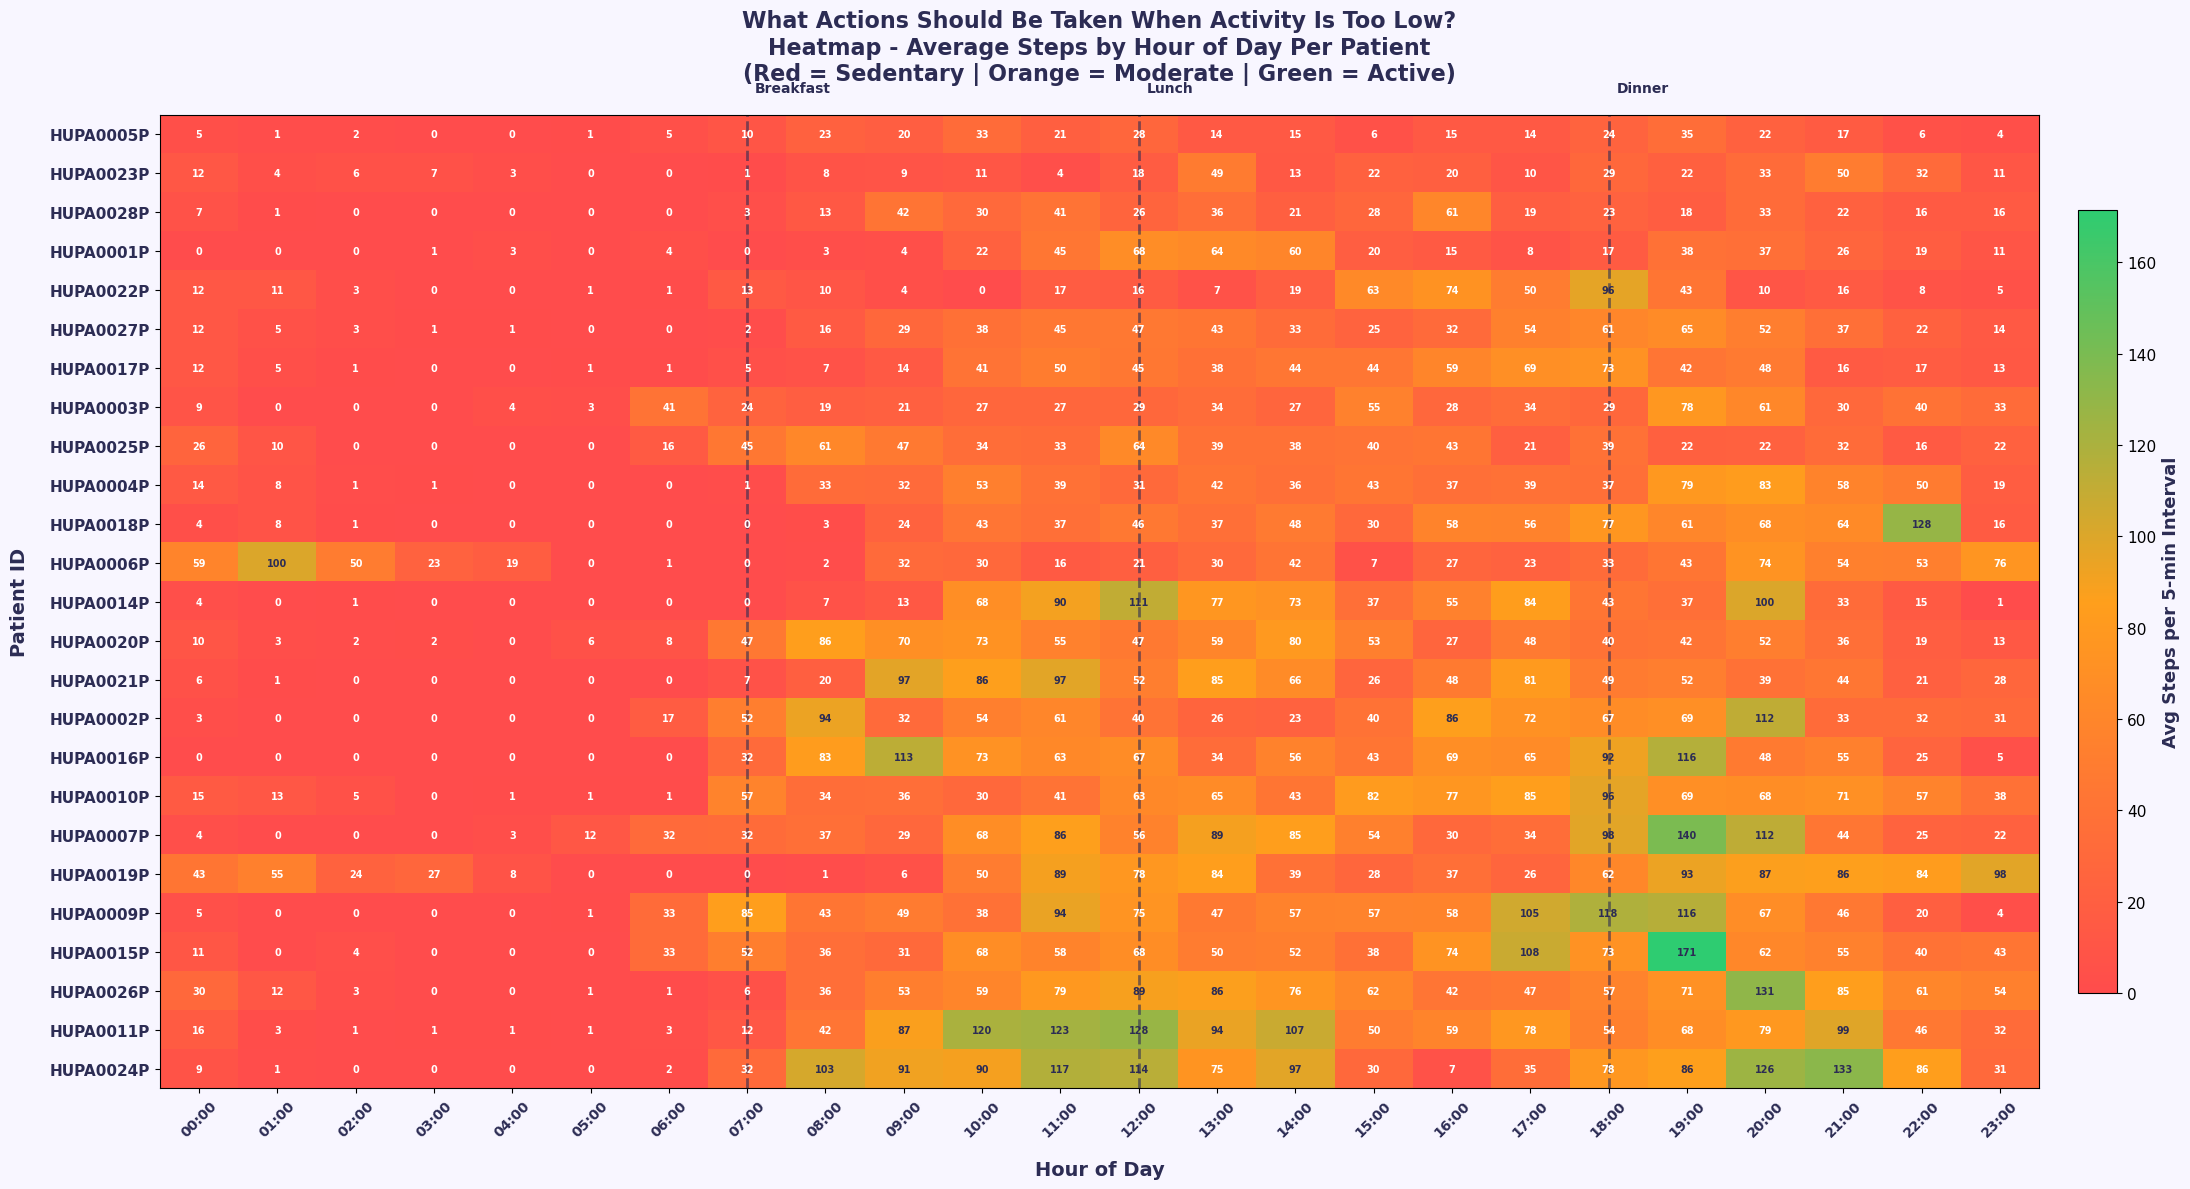

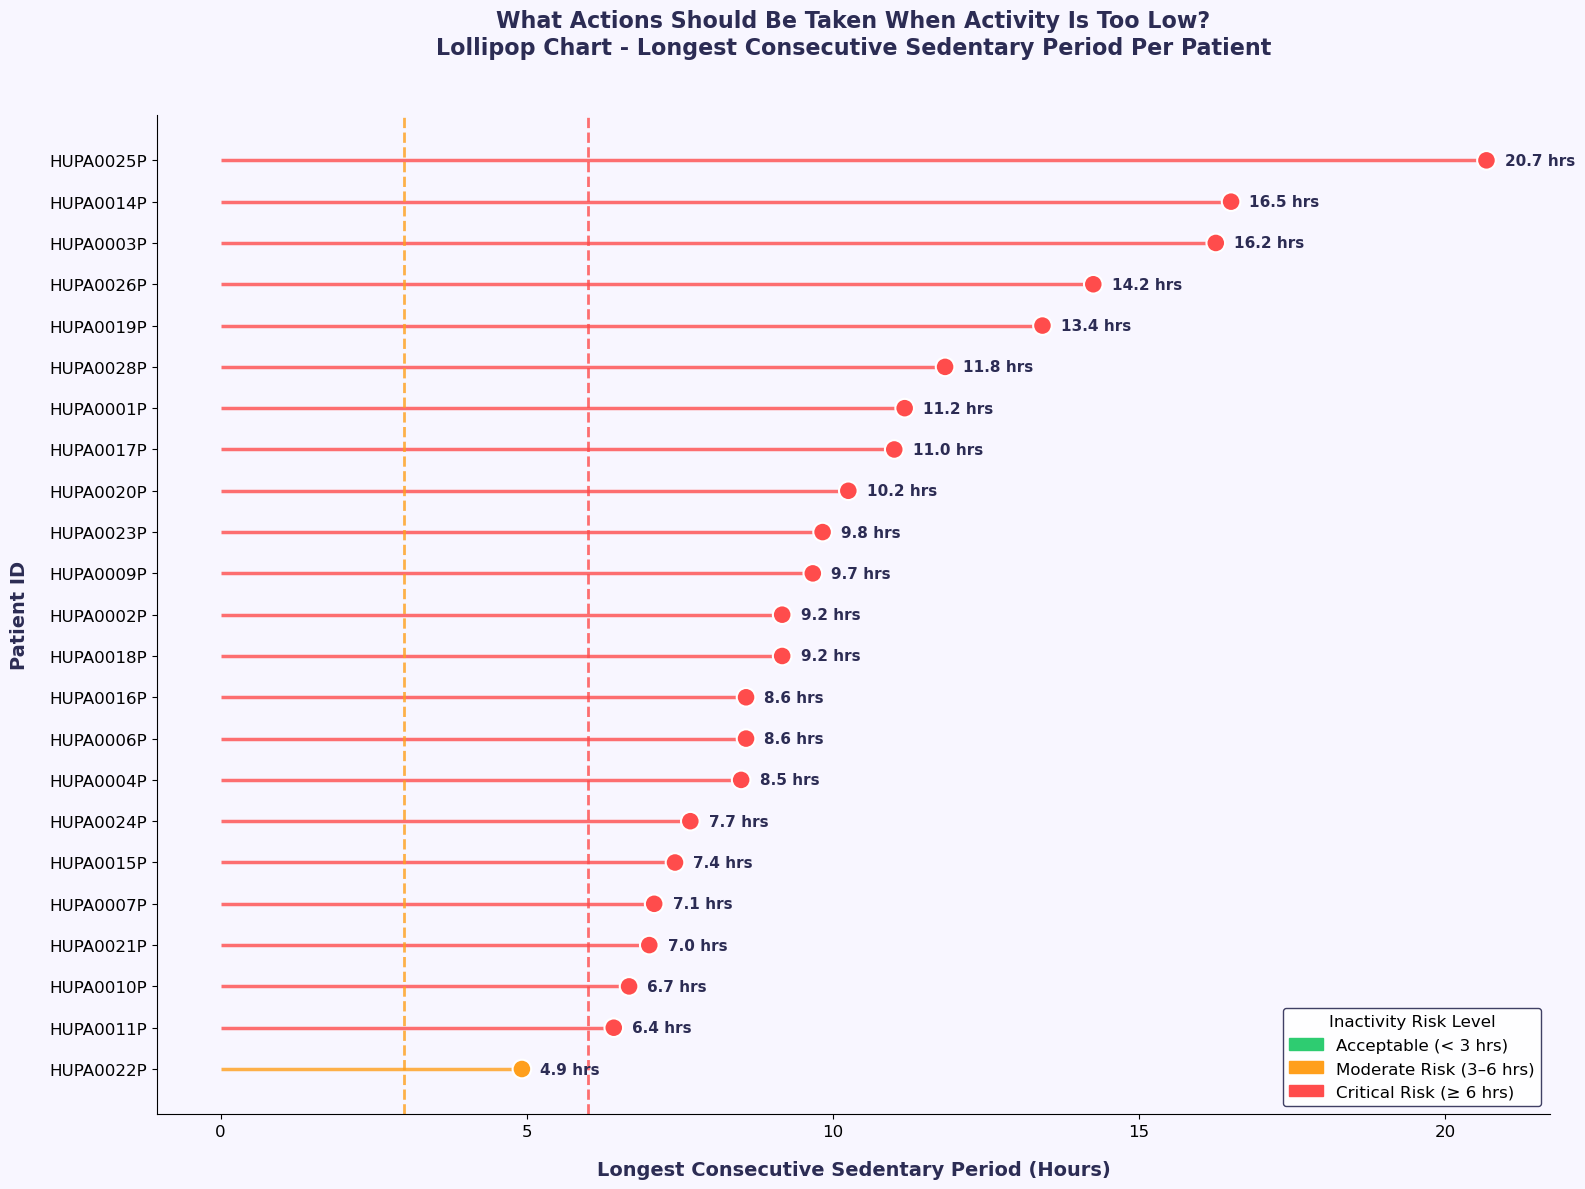

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Merged_Final.csv"
)

df['Time'] = pd.to_datetime(df['Time'], format='mixed')
df = df.sort_values(['Patient_Id', 'Time']).reset_index(drop=True)
df['Hour'] = df['Time'].dt.hour

bg_color = '#F8F6FF'

# ── Calculate Longest Sedentary Streak ───────────────────────────────────────
def longest_sedentary_streak(series):
    max_streak = 0
    current    = 0
    for val in series:
        if val == 0:
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0
    return max_streak * 5

streak_data = (
    df.groupby('Patient_Id')['Steps']
    .apply(longest_sedentary_streak)
    .reset_index()
)
streak_data.columns = ['Patient_Id', 'Longest_Sedentary_Minutes']
streak_data['Longest_Sedentary_Hours'] = (
    streak_data['Longest_Sedentary_Minutes'] / 60
).round(2)
streak_data = streak_data.sort_values(
    'Longest_Sedentary_Hours', ascending=True
).reset_index(drop=True)

def streak_color(hours):
    if hours >= 6:
        return '#FF4C4C'
    elif hours >= 3:
        return '#FF9F1C'
    else:
        return '#2ECC71'

streak_data['Color'] = streak_data['Longest_Sedentary_Hours'].apply(streak_color)

# ── Remove extreme outliers ───────────────────────────────────────────────────
outlier        = streak_data[streak_data['Longest_Sedentary_Hours'] > 50]
streak_display = streak_data[streak_data['Longest_Sedentary_Hours'] <= 50].copy()

outlier_note = ', '.join(
    [f"{row['Patient_Id']} ({row['Longest_Sedentary_Hours']} hrs)"
     for _, row in outlier.iterrows()]
)


# ════════════════════════════════════════════════════════════════
# CHART 1 — ACTIVITY HEATMAP
# ════════════════════════════════════════════════════════════════
heatmap_data = (
    df.groupby(['Patient_Id', 'Hour'])['Steps']
    .mean()
    .round(2)
    .unstack(fill_value=0)
)
heatmap_data = heatmap_data.loc[
    heatmap_data.mean(axis=1).sort_values().index
]

fig1, ax1 = plt.subplots(figsize=(22, 12))
fig1.patch.set_facecolor(bg_color)
ax1.set_facecolor(bg_color)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'activity', ['#FF4C4C', '#FF9F1C', '#2ECC71']
)

im = ax1.imshow(
    heatmap_data.values,
    aspect='auto',
    cmap=cmap,
    interpolation='nearest'
)

cbar = fig1.colorbar(im, ax=ax1, fraction=0.02, pad=0.02)
cbar.set_label('Avg Steps per 5-min Interval',
               fontsize=13, fontweight='bold', color='#2C2C54')
cbar.ax.tick_params(labelsize=11)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val        = heatmap_data.values[i, j]
        text_color = 'white' if val < heatmap_data.values.max() * 0.5 else '#2C2C54'
        ax1.text(j, i, f'{val:.0f}',
                 ha='center', va='center',
                 fontsize=7, color=text_color, fontweight='bold')

ax1.set_xticks(range(24))
ax1.set_xticklabels(
    [f'{h:02d}:00' for h in range(24)],
    fontsize=10, fontweight='bold', color='#2C2C54', rotation=45
)
ax1.set_yticks(range(len(heatmap_data.index)))
ax1.set_yticklabels(
    heatmap_data.index,
    fontsize=11, fontweight='bold', color='#2C2C54'
)
ax1.set_xlabel('Hour of Day',
               fontsize=14, fontweight='bold', color='#2C2C54', labelpad=15)
ax1.set_ylabel('Patient ID',
               fontsize=14, fontweight='bold', color='#2C2C54', labelpad=15)
ax1.set_title(
    'What Actions Should Be Taken When Activity Is Too Low?\n'
    'Heatmap - Average Steps by Hour of Day Per Patient\n'
    '(Red = Sedentary | Orange = Moderate | Green = Active)',
    fontsize=16, fontweight='bold', color='#2C2C54', pad=25
)

for meal_hour, label in [(7, 'Breakfast'), (12, 'Lunch'), (18, 'Dinner')]:
    ax1.axvline(x=meal_hour, color='#2C2C54',
                linewidth=2.0, linestyle='--', alpha=0.6)
    ax1.text(meal_hour + 0.1, -1.0, label,
             fontsize=10, fontweight='bold',
             color='#2C2C54', va='bottom')

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Prescriptive_Heatmap.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()


# ════════════════════════════════════════════════════════════════
# CHART 2 — LOLLIPOP CHART
# ════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(16, 12))
fig2.patch.set_facecolor(bg_color)
ax2.set_facecolor(bg_color)

ax2.hlines(
    y=streak_display['Patient_Id'],
    xmin=0,
    xmax=streak_display['Longest_Sedentary_Hours'],
    color=streak_display['Color'],
    linewidth=2.5,
    alpha=0.8
)

ax2.scatter(
    streak_display['Longest_Sedentary_Hours'],
    streak_display['Patient_Id'],
    color=streak_display['Color'],
    s=180,
    zorder=5,
    edgecolors='white',
    linewidths=1.5
)

for _, row in streak_display.iterrows():
    ax2.text(
        row['Longest_Sedentary_Hours'] + 0.3,
        row['Patient_Id'],
        f"{row['Longest_Sedentary_Hours']:.1f} hrs",
        va='center', fontsize=11,
        fontweight='bold', color='#2C2C54'
    )

ax2.axvline(x=3, color='#FF9F1C', linestyle='--',
            linewidth=2.0, alpha=0.8)
ax2.axvline(x=6, color='#FF4C4C', linestyle='--',
            linewidth=2.0, alpha=0.8)

ax2.set_xlabel('Longest Consecutive Sedentary Period (Hours)',
               fontsize=14, fontweight='bold', color='#2C2C54', labelpad=15)
ax2.set_ylabel('Patient ID',
               fontsize=14, fontweight='bold', color='#2C2C54', labelpad=15)
ax2.set_title(
    'What Actions Should Be Taken When Activity Is Too Low?\n'
    'Lollipop Chart - Longest Consecutive Sedentary Period Per Patient\n',

    fontsize=16, fontweight='bold', color='#2C2C54', pad=25
)
ax2.tick_params(axis='both', labelsize=12)
ax2.spines[['top', 'right']].set_visible(False)

patches = [
    mpatches.Patch(color='#2ECC71', label='Acceptable (< 3 hrs)'),
    mpatches.Patch(color='#FF9F1C', label='Moderate Risk (3–6 hrs)'),
    mpatches.Patch(color='#FF4C4C', label='Critical Risk (≥ 6 hrs)'),
]
ax2.legend(
    handles=patches,
    loc='lower right',
    bbox_to_anchor=(1.0, 0.0),
    fontsize=12,
    framealpha=0.9,
    edgecolor='#2C2C54',
    title='Inactivity Risk Level',
    title_fontsize=12
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Prescriptive_Lollipop.png",
    dpi=200, bbox_inches='tight', facecolor=bg_color
)
plt.show()


## Inactivity Alert Summary - Patients Requiring Activity Intervention 

In [66]:
from IPython.display import display, HTML

# ── Inactivity Summary Table ──────────────────────────────────────────────────
critical  = streak_display[streak_display['Longest_Sedentary_Hours'] >= 6]
moderate  = streak_display[(streak_display['Longest_Sedentary_Hours'] >= 3) & 
                            (streak_display['Longest_Sedentary_Hours'] < 6)]
acceptable = streak_display[streak_display['Longest_Sedentary_Hours'] < 3]

summary_rows = [
    ('Most Sedentary Patient (in chart)',   f"{streak_display.iloc[-1]['Patient_Id']} ({streak_display.iloc[-1]['Longest_Sedentary_Hours']} hrs)"),
    ('Least Sedentary Patient (in chart)',  f"{streak_display.iloc[0]['Patient_Id']} ({streak_display.iloc[0]['Longest_Sedentary_Hours']} hrs)"),
    ('Critical Risk Patients (≥ 6 hrs)',    f"{len(critical)} patients — {', '.join(critical.sort_values('Longest_Sedentary_Hours', ascending=False)['Patient_Id'].tolist())}"),
    ('Moderate Risk Patients (3–6 hrs)',    f"{len(moderate)} patients — {', '.join(moderate['Patient_Id'].tolist())}"),
    ('Acceptable Patients (< 3 hrs)',       f"{len(acceptable)} patients" if len(acceptable) > 0 else "0 patients — None in chart"),
]

row_colors = [
    '#FF4C4C',   # Most sedentary — red
    '#2ECC71',   # Least sedentary — green
    '#5C6BC0',   # Outliers — indigo
    '#FF4C4C',   # Critical — red
    '#FF9F1C',   # Moderate — orange
    '#2ECC71',   # Acceptable — green
]

html = (
    "<style>"
    ".inactivity-table { border-collapse: collapse; width: 90%; font-family: Arial, sans-serif; font-size: 13px; }"
    ".inactivity-table th { padding: 12px 16px; text-align: center; font-weight: bold; color: white; font-size: 14px; background-color: #2C2C54; }"
    ".inactivity-table td { padding: 10px 16px; border: 1px solid #ddd; font-size: 13px; color: #2C2C54; }"
    ".metric-col { font-weight: bold; width: 30%; background-color: #2C2C54 !important; color: white !important; }"
    "</style>"
    "<h3 style='font-family:Arial; color:#2C2C54;'>Inactivity Alert Summary — Patients Requiring Activity Intervention</h3>"
    "<table class='inactivity-table'>"
    "<thead><tr>"
    "<th>Metric</th>"
    "<th>Value</th>"
    "</tr></thead><tbody>"
)

for (metric, value), color in zip(summary_rows, row_colors):
    html += (
        f"<tr>"
        f"<td class='metric-col'>{metric}</td>"
        f"<td style='background-color:{color}20; color:#2C2C54; font-weight:bold;'>{value}</td>"
        f"</tr>"
    )

html += "</tbody></table>"

display(HTML(html))

Metric,Value
Most Sedentary Patient (in chart),HUPA0025P (20.67 hrs)
Least Sedentary Patient (in chart),HUPA0022P (4.92 hrs)
Critical Risk Patients (≥ 6 hrs),"22 patients — HUPA0025P, HUPA0014P, HUPA0003P, HUPA0026P, HUPA0019P, HUPA0028P, HUPA0001P, HUPA0017P, HUPA0020P, HUPA0023P, HUPA0009P, HUPA0018P, HUPA0002P, HUPA0006P, HUPA0016P, HUPA0004P, HUPA0024P, HUPA0015P, HUPA0007P, HUPA0021P, HUPA0010P, HUPA0011P"
Moderate Risk Patients (3–6 hrs),1 patients — HUPA0022P
Acceptable Patients (< 3 hrs),0 patients — None in chart


#### Prescriptive Insight
#### The heatmap confirms that nearly all patients show deep red (sedentary) between midnight and 6AM and during critical post-meal windows at 7AM, 12PM and 6PM. Notably HUPA0006P shows the highest activity at 9AM–10AM (100+ steps) while most others remain red throughout the day. This pattern highlights the urgent need for short 10–15 minute walks after every meal to naturally reduce post-meal glucose spikes.
#### The lollipop charts shows all 23 out of 23 displayed patients fall in the critical risk zone with sedentary streaks exceeding 6 hours. HUPA0025P has the longest streak at 20.7 hours, followed by HUPA0014P (16.5 hrs) and HUPA0003P (16.2 hrs). Only HUPA0022P falls in the moderate zone at 4.9 hours making them the most active patient in the chart. Two patients (HUPA0005P at 99.75 hrs and HUPA0027P at 382.67 hrs) were excluded as extreme outliers but represent the most critical cases requiring immediate intervention.
#### Overall The data shows that prolonged inactivity is not an exception — it is the norm across this entire patient group. Since physical movement is one of the simplest and most effective ways to lower glucose without medication, clinicians should make regular movement breaks every 2–3 hours and post-meal walking routines a standard non-negotiable part of every T1DM patient's treatment plan — starting with the highest risk patients HUPA0025P, HUPA0014P and HUPA0003P.